In [1]:
from spin_lattices import KagomeLattice, SpinLattice, SquareLattice, TriangularLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from fast_boolean_analysis import (
    keep_largest_n,
    keep_everything,
    ScorerType,
    get_scorer,
    FourierSeries,
    fourier_expand,
)

import re

from lattice_boolean_analysis import (
    AmplitudeMedianBinSignalKind,
    SignSignalKind,
    AmplitudeSignalKind,
    SignalKind,
    LBFFromSpinSystem,
)

import json

from loguru import logger

from pathlib import Path
import numpy as np
import pandas as pd
import lattice_symmetries as ls
import matplotlib.pyplot as plt
from itertools import product
import numpy.typing as npt
from tqdm import tqdm
import seaborn as sns

# import parse
import sys
from typing import NamedTuple
from misc_utils import read_jsonl_to_df

from parity import popcount
from dataclasses import dataclass, astuple

ground_state_cache_dir = Path("groundstates")

outdir = Path("experiments/boolean-analysis-complexity")
outdir.mkdir(exist_ok=True, parents=True)


def get_score_column(df: pd.DataFrame, scorer: str) -> list:
    return [
        row["series"]
        .truncate(keep_largest_n(row["terms"]))
        .prediction_score(scorer=scorer)
        for _, row in (df.iterrows())
    ]


logger.remove()
logger.add(Path("boolean-analysis-complexity.ipynb.log", level="DEBUG", colorize=True))


class LatticeOptions(NamedTuple):
    lattice: SpinLattice
    use_symmetries: bool
    max_terms: int | None


lattice_opts = [
    LatticeOptions(
        lattice=SquareLattice(width=4, height=4), use_symmetries=True, max_terms=None
    ),
    LatticeOptions(
        lattice=SquareLattice(width=4, height=5),
        use_symmetries=False,
        max_terms=2**11,
    ),
    LatticeOptions(
        lattice=SquareLattice(width=4, height=6), use_symmetries=True, max_terms=2**15
    ),
    LatticeOptions(
        TriangularLattice(width=4, height=4), use_symmetries=True, max_terms=None
    ),
    LatticeOptions(
        TriangularLattice(width=4, height=5), use_symmetries=False, max_terms=2**11
    ),
    LatticeOptions(
        TriangularLattice(width=4, height=6), use_symmetries=True, max_terms=2**15
    ),
    LatticeOptions(
        KagomeLattice(width=2, height=2), use_symmetries=False, max_terms=None
    ),
    LatticeOptions(
        KagomeLattice(width=2, height=3), use_symmetries=False, max_terms=None
    ),
    LatticeOptions(
        KagomeLattice(width=2, height=4), use_symmetries=True, max_terms=2**16
    ),
    LatticeOptions(
        SquareLattice(width=7, height=4), False, max_terms=2 ** (16 + 5 + 2)
    ),
    LatticeOptions(
        TriangularLattice(width=7, height=4), False, max_terms=2 ** (16 + 5 + 2)
    ),
    LatticeOptions(
        TriangularLattice(width=5, height=6), False, max_terms=2 ** (16 + 5 + 5)
    ),
    LatticeOptions(
        KagomeLattice(width=2, height=5), False, max_terms=2 ** (16 + 5 + 5)
    ),
    LatticeOptions(
        SquareLattice(width=5, height=6), False, max_terms=2 ** (16 + 5 + 5)
    ),
    LatticeOptions(KagomeLattice(width=3, height=3), False, max_terms=2 ** (16 + 5)),
]

In [2]:
%matplotlib inline

In [17]:
name_to_lat_and_sym = {
    lat_opt.lattice.get_cache_id(): (lat_opt.lattice, lat_opt.use_symmetries)
    for lat_opt in lattice_opts
}

name_to_lat_and_sym |= {
    "TriangleLattice4x4": name_to_lat_and_sym["TriangularLattice4x4"],
    "TriangleLattice4x5": name_to_lat_and_sym["TriangularLattice4x5"],
    "TriangleLattice4x6": name_to_lat_and_sym["TriangularLattice4x6"],
    "TriangleLattice5x6": name_to_lat_and_sym["TriangularLattice5x6"],
    "TriangleLattice7x4": name_to_lat_and_sym["TriangularLattice7x4"],
}

name_to_signal_kind = {
    signal.name: signal for signal in [AmplitudeMedianBinSignalKind(), SignSignalKind()]
}

In [18]:
full_df = pd.DataFrame(
    [json.loads(file.read_text()) for file in outdir.glob("*.json")]
).sort_values(["lattice_name", "J2", "signal_kind"])

In [19]:
full_df['target_scorer'].unique()

array(['f1'], dtype=object)

In [20]:
series_df = (
    full_df.assign(
        mean_hw=lambda df: df["total_hamming_weight"] / df["terms"],
        relative_fourier_weight=lambda df: df["terms_fourier_weight"]
        / df["total_fourier_weight"],
    )
    .assign(
        lattice_type=lambda df: df["lattice_name"].str.replace(r"\d.+", "", regex=True),
        number_spins=lambda df: df["lattice_name"].map(
            lambda name: name_to_lat_and_sym[name][0].number_spins
        ),
    )
    .sort_values(["lattice_type", "number_spins", "J2", "signal_kind"])
    .set_index(["lattice_name", "J2", "signal_kind"])
)

In [21]:
np.log2(
    series_df.query('lattice_name.str.startswith("Kagome")')
    .groupby("number_spins")["terms"]
    .max()
)

number_spins
12     5.954196
18    10.336507
24    14.882500
27    18.187342
30    19.807896
Name: terms, dtype: float64

In [22]:
%matplotlib inline

In [23]:
series_df.loc["TriangleLattice4x6", 1.0, "sign"]["total_hamming_weight"]

49742

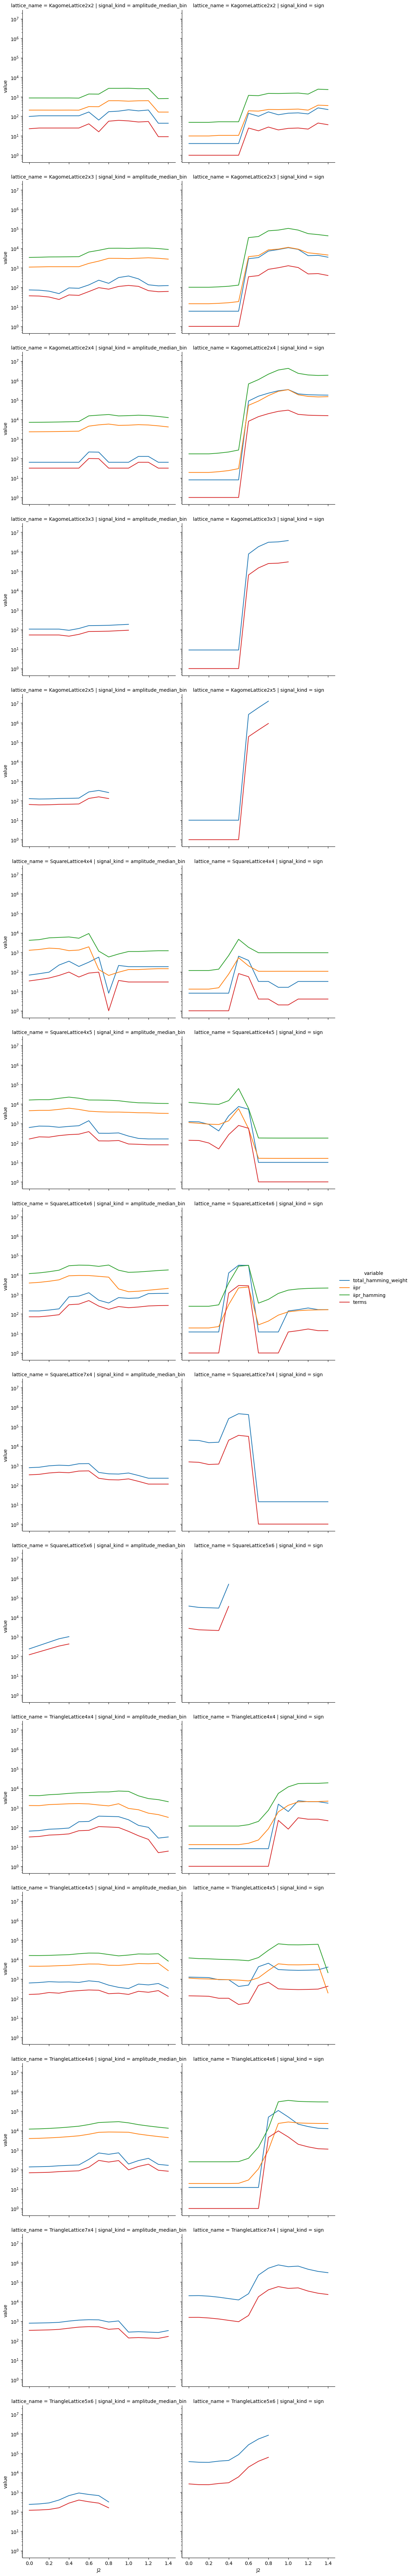

In [9]:
sns.relplot(
    series_df.reset_index()
    .assign(
        iipr_hamming=lambda df: 1 / df["ipr_hamming"],
        iipr=lambda df: 1 / df["ipr"],
    )
    .melt(
        id_vars=["lattice_name", "J2", "signal_kind"],
        value_vars=["total_hamming_weight", "iipr", "iipr_hamming", "terms"],
    )
    .dropna(),
    x="J2",
    y="value",
    hue="variable",
    row="lattice_name",
    col="signal_kind",
    kind="line",
).set(yscale="log")

In [12]:
series_df.columns

Index(['success', 'terms', 'target_score', 'target_scorer', 'sign_overlap',
       'accuracy', 'f1', 'total_hamming_weight', 'number_spins',
       'largest_terms', 'largest_coeffs', 'total_fourier_weight',
       'terms_fourier_weight', 'rel_weight_terms', 'rel_weight_target',
       'rel_weight_total_hamming_weight', 'rel_weight_subsets',
       'rel_weight_coeffs', 'ipr', 'ipr_hamming', 'mean_hw',
       'relative_fourier_weight', 'lattice_type'],
      dtype='object')

/tmp/nix-shell.c6kGom/ipykernel_2070777/805948479.py:1: UserWarning: 
The markers list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.relplot(


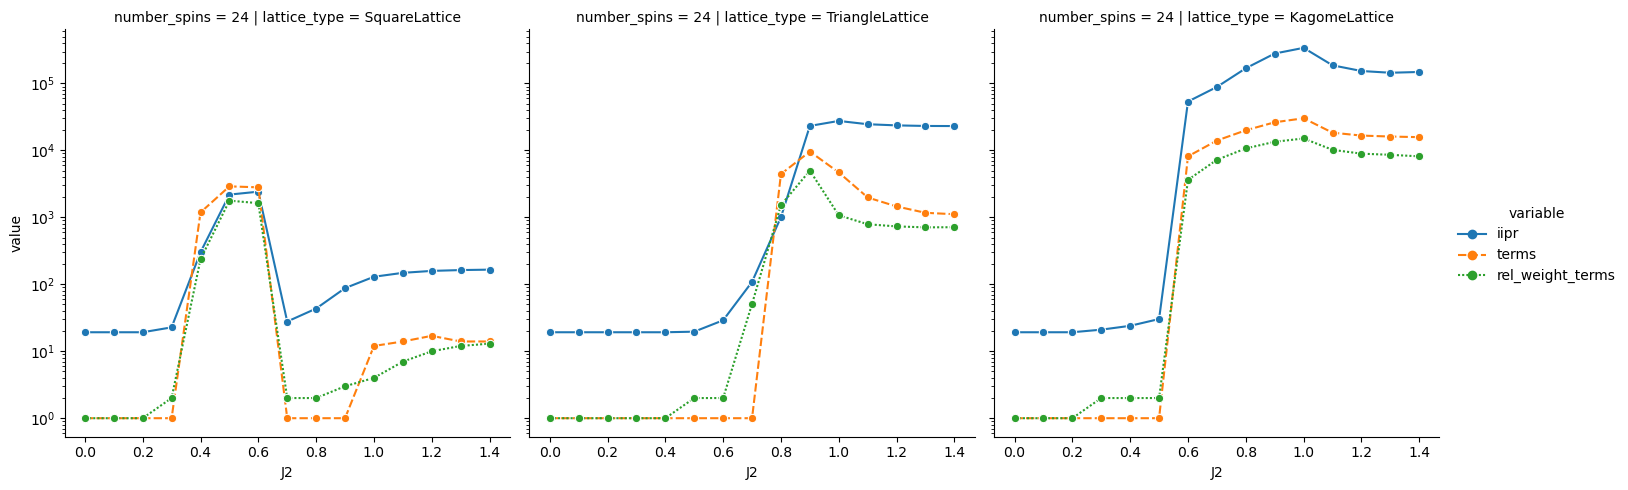

In [21]:
sns.relplot(
    series_df.reset_index()
    .query('signal_kind == "sign" and number_spins == 24')
    .assign(
        iipr_hamming=lambda df: 1 / df["ipr_hamming"],
        iipr=lambda df: 1 / df["ipr"],
    )
    .melt(
        id_vars=["lattice_type", "number_spins", "J2", "signal_kind"],
        value_vars=["iipr", "terms", "rel_weight_terms"],
    )
    .dropna(),
    x="J2",
    y="value",
    hue="variable",
    col="lattice_type",
    row="number_spins",
    kind="line",
    markers=['o'],
    style='variable',
    col_order=['SquareLattice', "TriangleLattice", "KagomeLattice"]
).set(yscale="log")
plt.savefig("fig/boolean-analysis-complexity-1.png")

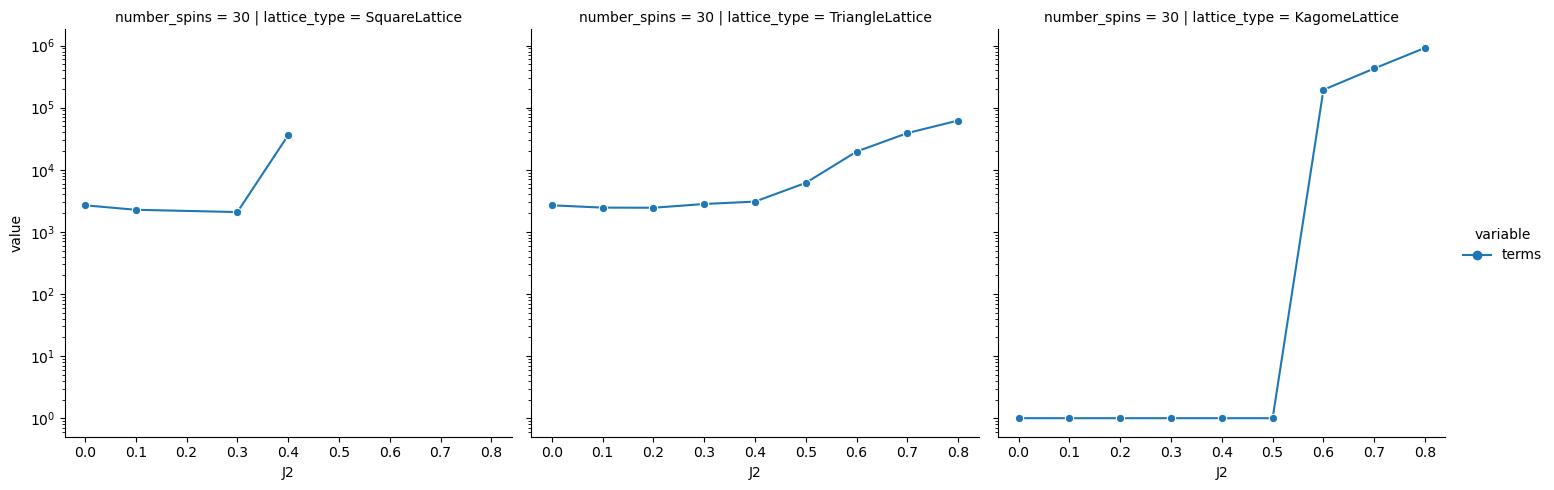

In [59]:
sns.relplot(
    series_df.reset_index()
    .query('signal_kind == "sign" and number_spins == 30')
    .assign(
        iipr_hamming=lambda df: 1 / df["ipr_hamming"],
        iipr=lambda df: 1 / df["ipr"],
    )
    .melt(
        id_vars=["lattice_type", "number_spins", "J2", "signal_kind"],
        value_vars=["iipr", "terms", "rel_weight_terms"],
    )
    .dropna(),
    x="J2",
    y="value",
    hue="variable",
    col="lattice_type",
    row="number_spins",
    kind="line",
    markers=['o'],
    style='variable',
    col_order=['SquareLattice', "TriangleLattice", "KagomeLattice"]
).set(yscale="log")


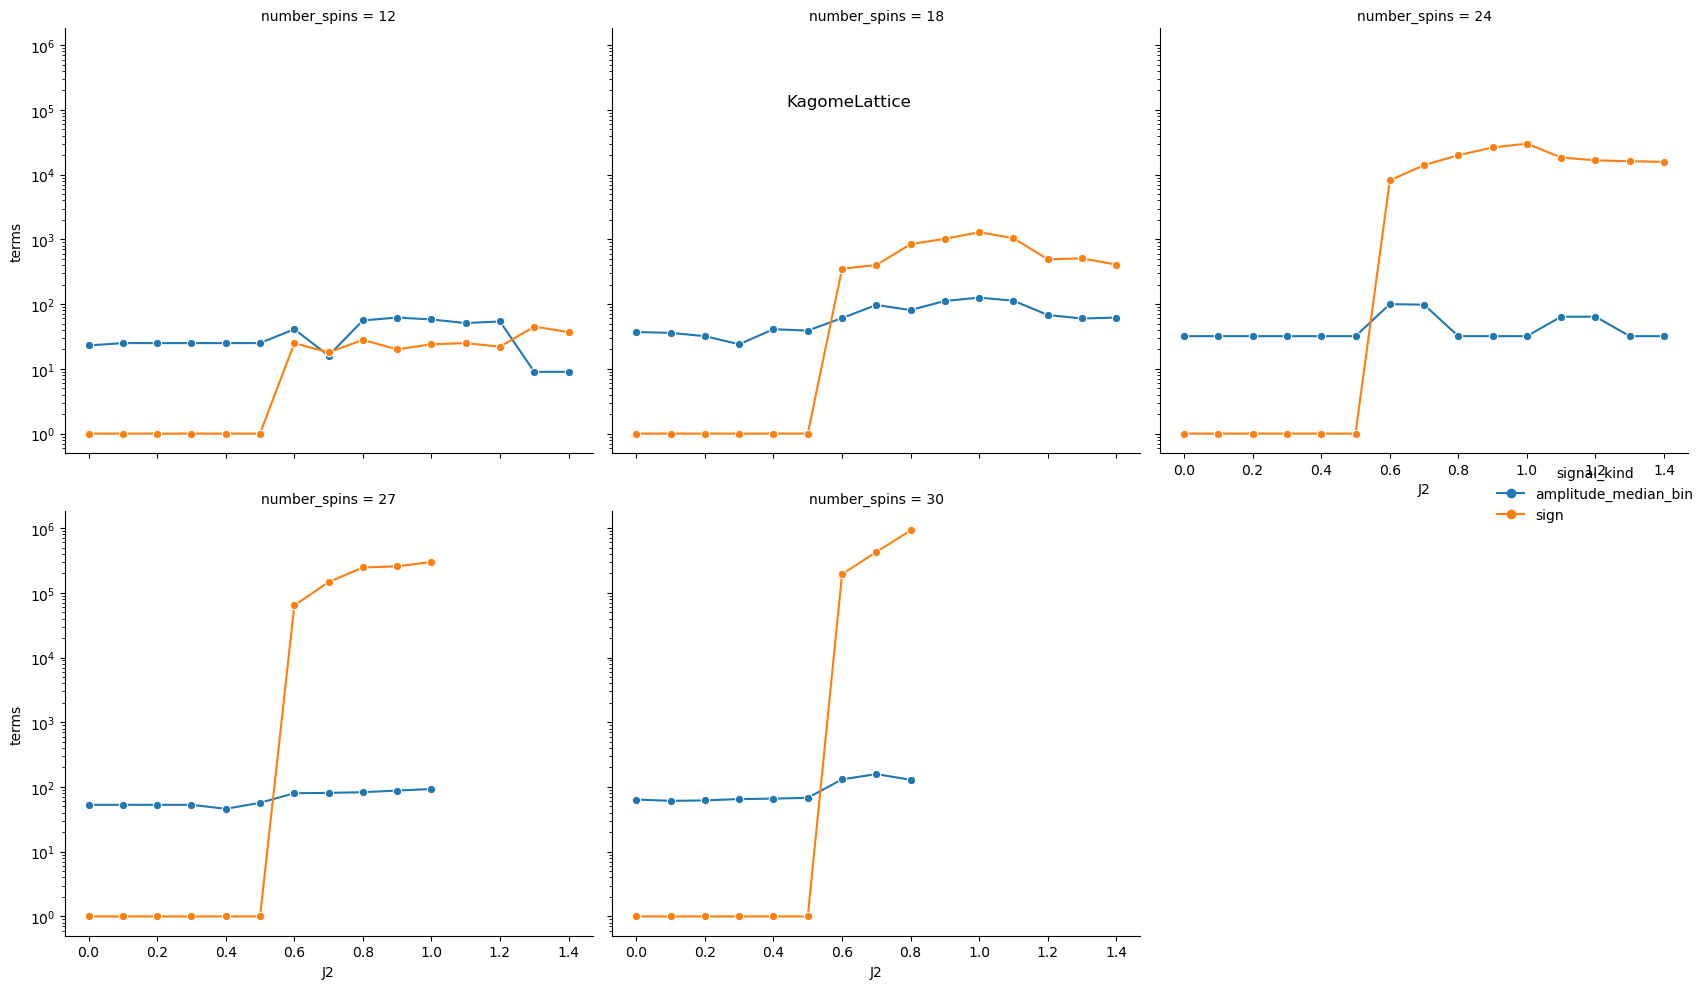

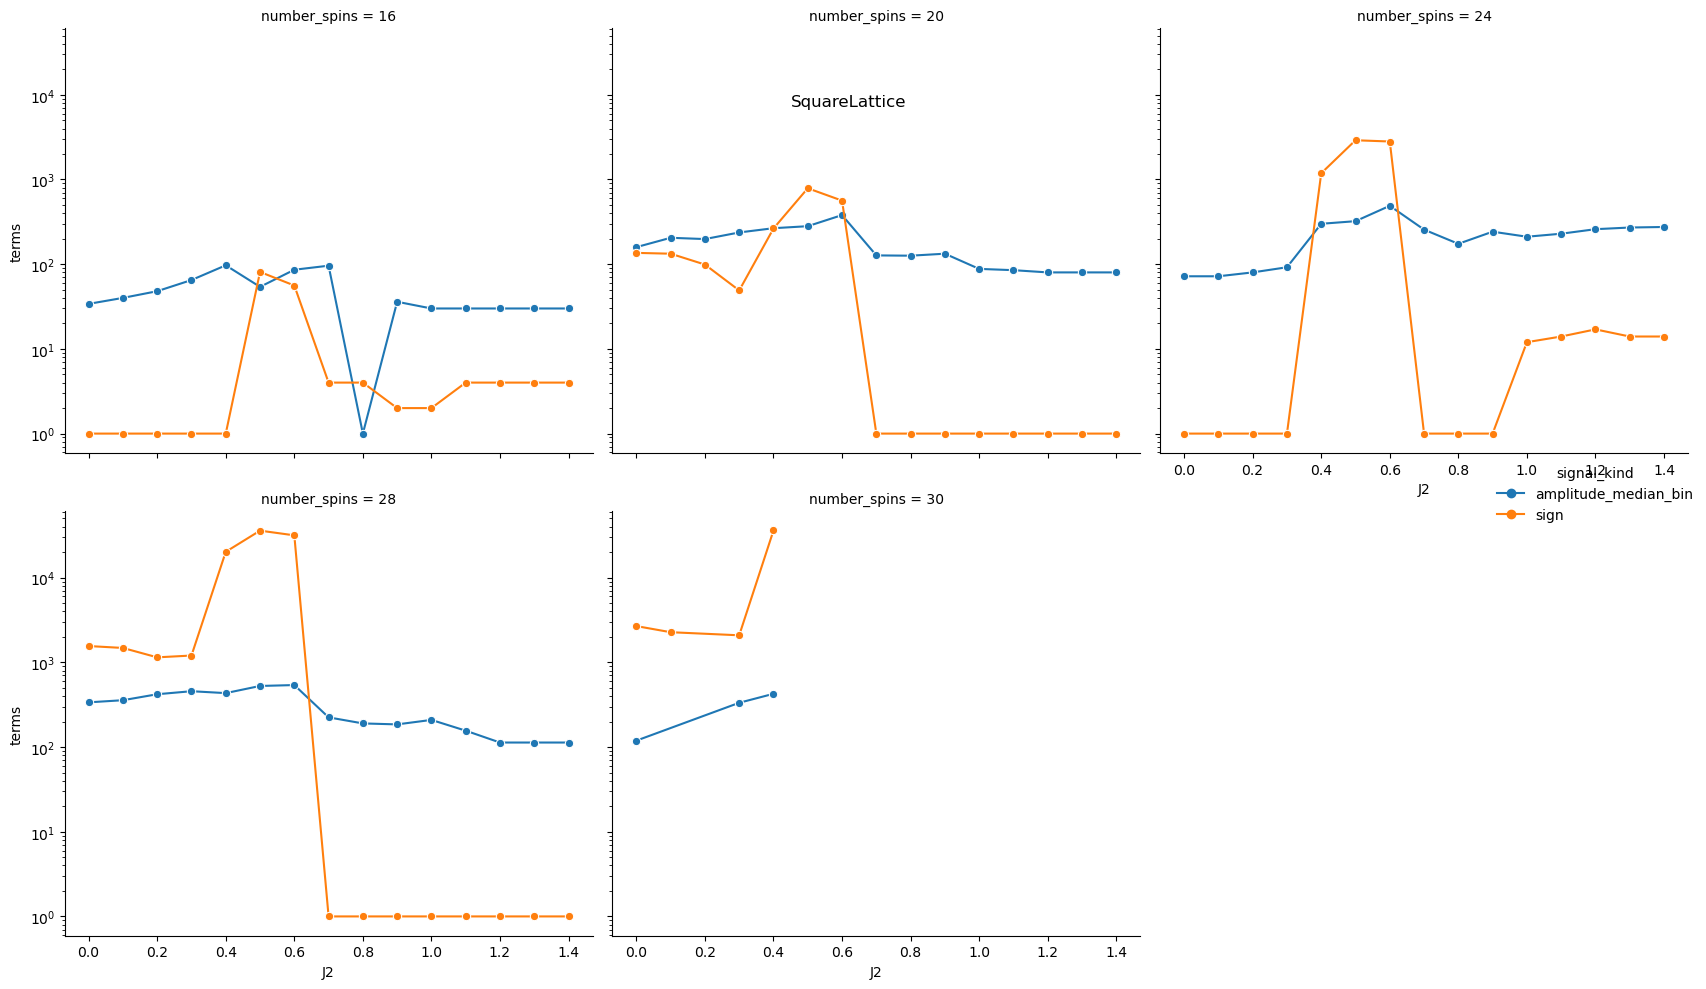

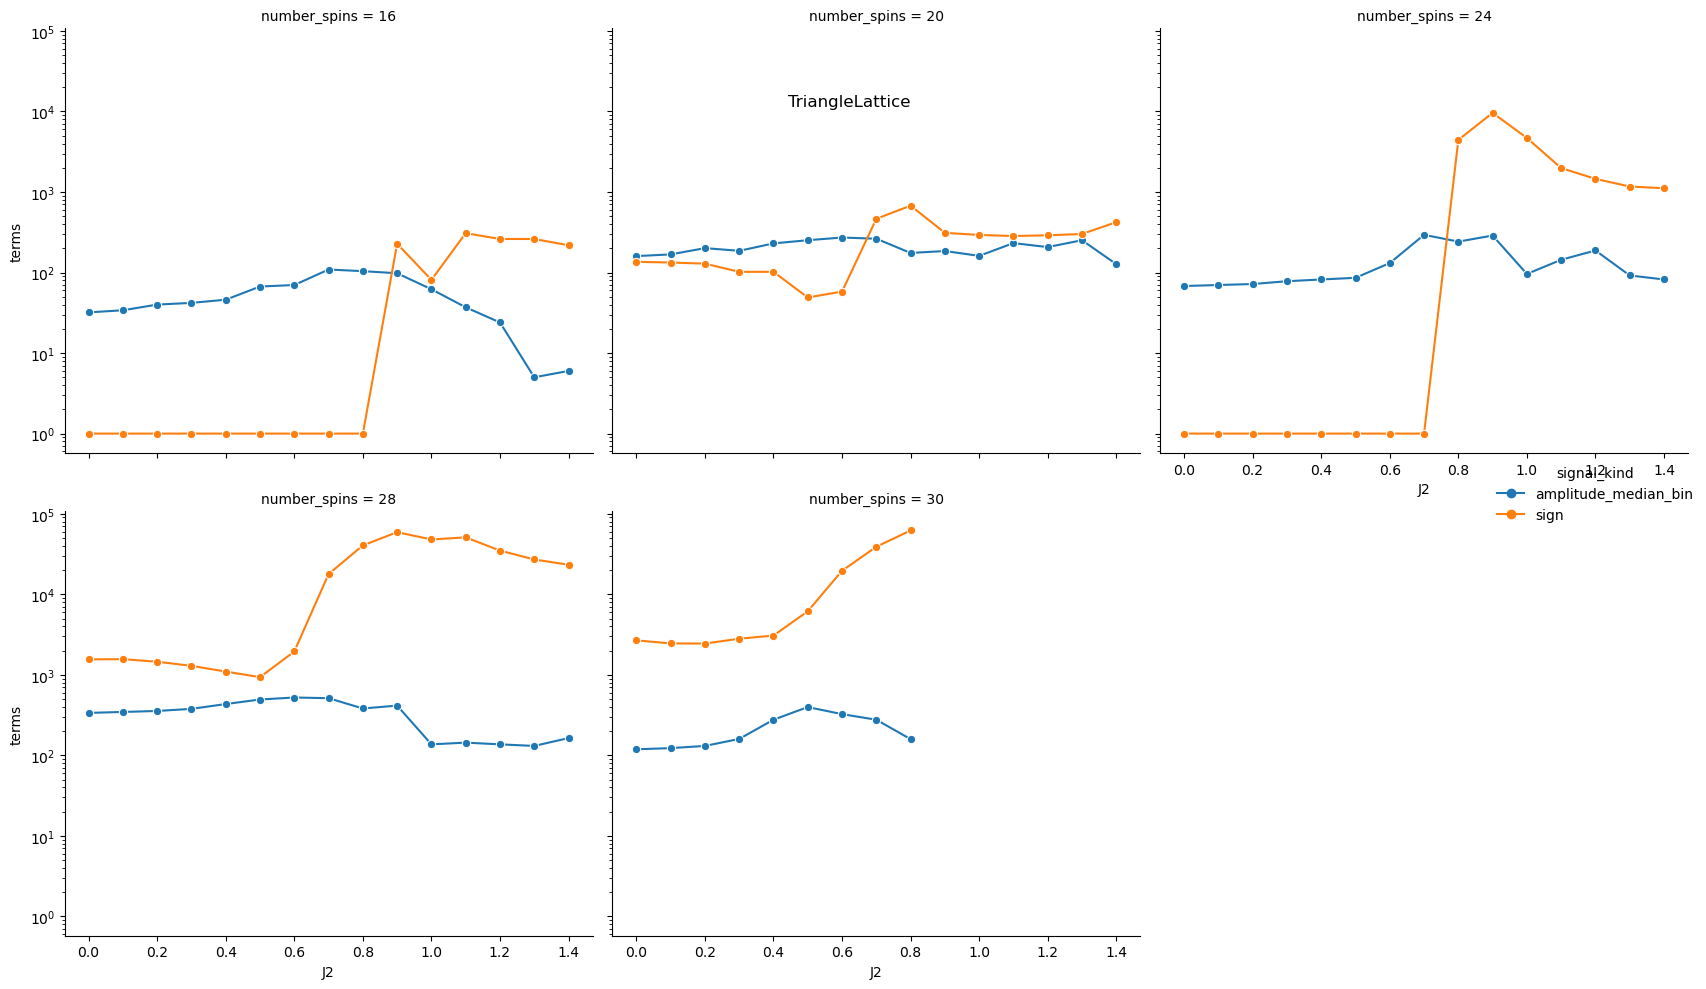

In [50]:
for lattice_type, df in series_df.reset_index().groupby("lattice_type"):
    g = sns.relplot(
        df,  # .query("number_spins < 28"),
        x="J2",
        y="terms",
        hue="signal_kind",
        col="number_spins",
        col_wrap=3,
        kind="line",
        # markers=True,
        style="signal_kind",
        dashes=False,
        markers=["o", "o"],
        # make y axis independent
        # facet_kws=dict(sharey=False),
    )  # log scale
    g.set(yscale="log")
    g.fig.tight_layout()
    g.fig.suptitle(f"{lattice_type}", y=0.9)

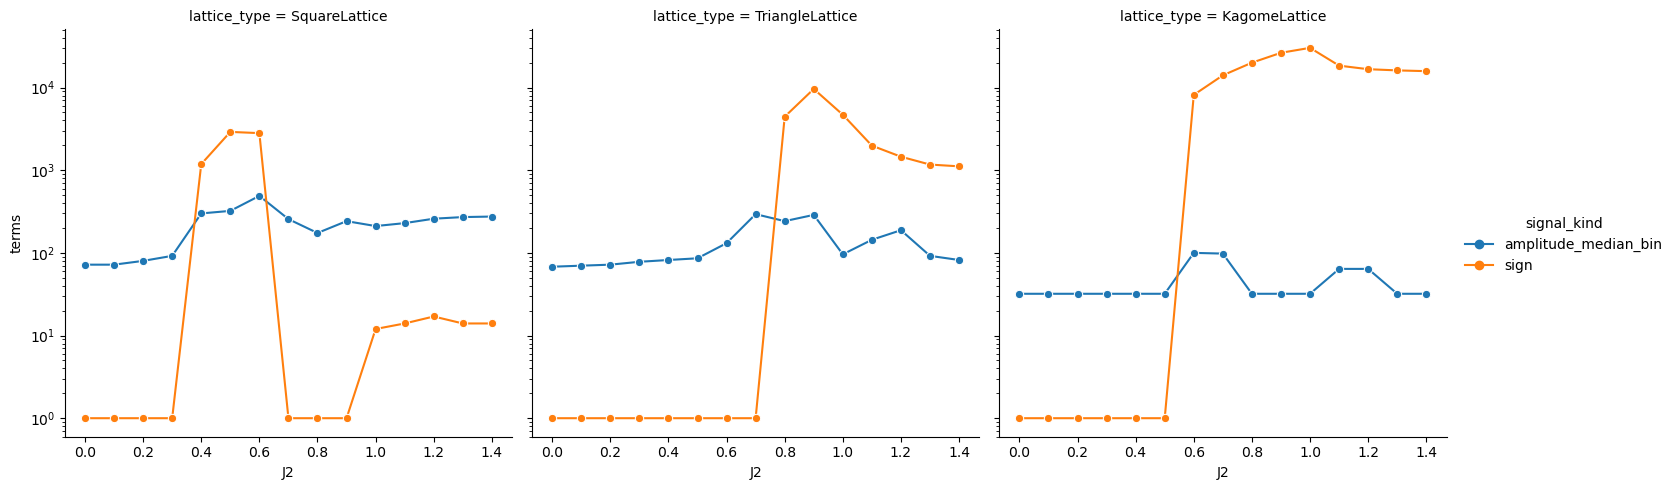

In [72]:
# for lattice_type, df in series_df.reset_index().groupby("lattice_type"):
sns.relplot(
    series_df.reset_index().query("number_spins == 24"),
    x="J2",
    y="terms",
    hue="signal_kind",
    col="lattice_type",
    kind="line",
    # markers=True,
    style="signal_kind",
    dashes=False,
    markers=["o", "o"],
    col_order=["SquareLattice", "TriangleLattice", "KagomeLattice"],
    # make y axis independent
    # facet_kws=dict(sharey=False),
).set(yscale="log")
plt.savefig("fig/boolean-analysis-complexity-5.png")

In [11]:
(
    series_df.query("number_spins == 24")
    .reset_index()
    .groupby(["lattice_name", "signal_kind"])[["terms", "ipr_hamming"]]
    .max()
)

terms  ipr_hamming
lattice_name       signal_kind                             
KagomeLattice2x4   amplitude_median_bin    100     0.000140
                   sign                  30205     0.005779
SquareLattice4x6   amplitude_median_bin    489     0.000084
                   sign                   2906     0.004001
TriangleLattice4x6 amplitude_median_bin    294     0.000084
                   sign                   9614     0.004001

In [9]:
series_df.columns

Index(['success', 'terms', 'target_score', 'target_scorer', 'sign_overlap',
       'accuracy', 'f1', 'total_hamming_weight', 'number_spins',
       'largest_terms', 'largest_coeffs', 'total_fourier_weight',
       'terms_fourier_weight', 'rel_weight_terms', 'rel_weight_target',
       'rel_weight_total_hamming_weight', 'rel_weight_subsets',
       'rel_weight_coeffs', 'ipr', 'ipr_hamming', 'mean_hw',
       'relative_fourier_weight', 'lattice_type'],
      dtype='object')

<Axes: xlabel='lattice_name', ylabel='rel_weight_terms'>

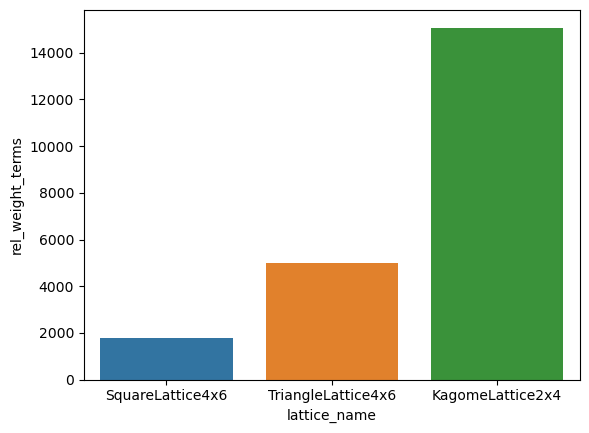

In [10]:
sns.barplot(
    series_df.query("number_spins == 24 and signal_kind == 'sign'")
    .reset_index()
    .groupby(["lattice_name", "signal_kind"])[["terms", "ipr_hamming", "rel_weight_terms"]]
    .max()
    .sort_values("terms")
    .reset_index(),
    x="lattice_name",
    y="rel_weight_terms",
)
# plt.savefig("fig/boolean-analysis-complexity-2.png")

In [47]:
difficult_J2s = pd.DataFrame([{"lattice_type": "KagomeLattice", "J2": 1},
                              {"lattice_type": "SquareLattice", "J2": 0.5},
                              {"lattice_type": "TriangleLattice", "J2": 1}])

easy_J2s = pd.DataFrame([{"lattice_type": "KagomeLattice", "J2": 0.4},
                              {"lattice_type": "SquareLattice", "J2": 0.3},
                              {"lattice_type": "TriangleLattice", "J2": 0.4}])

In [38]:
difficult_J2s

,lattice_type,J2
0,KagomeLattice,1.0
1,SquareLattice,0.5
2,TriangleLattice,1.0


In [48]:
series_df.reset_index().query('signal_kind == "sign"').merge(
    difficult_J2s, on=["lattice_type", "J2"], how="right"
)

,lattice_name,J2,signal_kind,success,terms,target_score,target_scorer,sign_overlap,accuracy,f1,...,rel_weight_terms,rel_weight_target,rel_weight_total_hamming_weight,rel_weight_subsets,rel_weight_coeffs,ipr,ipr_hamming,mean_hw,relative_fourier_weight,lattice_type
0,KagomeLattice2x2,1.0,sign,True,24,0.8,f1,0.868637,0.795455,0.804646,...,12.0,0.16,72.0,"[3633, 462, 1954, 2141, 1644, 2451, 1737, 2358...","[-4.59375, -4.59375, -3.71875, -3.71875, -3.59...",0.004403,6.597785e-04,6.000000,0.231255,KagomeLattice
1,KagomeLattice2x3,1.0,sign,True,1293,0.8,f1,0.950984,0.800473,0.800247,...,548.0,0.16,4688.0,"[55753, 206390, 52844, 209299, 85395, 176748, ...","[-5.24609375, 5.24609375, -5.19140625, 5.19140...",0.000088,9.373465e-06,8.432328,0.264575,KagomeLattice
2,KagomeLattice2x4,1.0,sign,True,30205,0.8,f1,0.985646,0.799662,0.800052,...,15078.0,0.16,174504.0,"[9202588, 7574627, 5071673, 13733093, 11705542...","[-10.7080078125, -10.7080078125, -10.708007812...",0.000003,2.372145e-07,11.395531,0.227470,KagomeLattice
3,KagomeLattice3x3,1.0,sign,True,298494,0.8,f1,0.993358,0.799993,0.800004,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.431526,0.222198,KagomeLattice
4,SquareLattice4x4,0.5,sign,True,81,0.8,f1,0.848244,0.801088,0.800933,...,48.0,0.16,384.0,"[42342, 15450, 23193, 38550, 43571, 50085, 269...","[13.5234375, 13.5234375, 13.5234375, 13.523437...",0.001895,2.142970e-04,7.827160,0.191356,SquareLattice
5,SquareLattice4x5,0.5,sign,True,788,0.8,f1,0.965890,0.802247,0.801081,...,502.0,0.16,4780.0,"[857753, 444838, 603737, 667237, 381338, 73072...","[-24.51953125, -24.51953125, -24.51953125, -24...",0.000175,1.628838e-05,9.340102,0.194404,SquareLattice
6,SquareLattice4x6,0.5,sign,True,2906,0.8,f1,0.923779,0.799566,0.800024,...,1777.0,0.16,19810.0,"[5594316, 11097702, 5679513, 11182899, 1109852...","[168.3115234375, 168.3115234375, 168.311523437...",0.000457,3.521097e-05,10.992429,0.188246,SquareLattice
7,SquareLattice7x4,0.5,sign,True,35873,0.8,f1,0.956465,0.800248,0.800013,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.867951,0.183809,SquareLattice
8,TriangleLattice4x4,1.0,sign,True,81,0.8,f1,0.990751,0.792541,0.806774,...,100.0,0.16,800.0,"[23193, 14772, 39981, 25554, 38550, 43571, 154...","[9.2734375, 9.2734375, 9.2734375, 9.2734375, 9...",0.000742,8.389888e-05,8.000000,0.146574,TriangleLattice
9,TriangleLattice4x5,1.0,sign,True,293,0.8,f1,0.946171,0.801533,0.800442,...,203.0,0.16,1950.0,"[682201, 366374, 861618, 186957, 861990, 70727...","[12.87890625, 12.87890625, 12.82421875, 12.824...",0.000187,1.758776e-05,9.726962,0.211836,TriangleLattice


/tmp/nix-shell.c6kGom/ipykernel_2070777/3367307720.py:1: UserWarning: 
The markers list has fewer values (1) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.relplot(


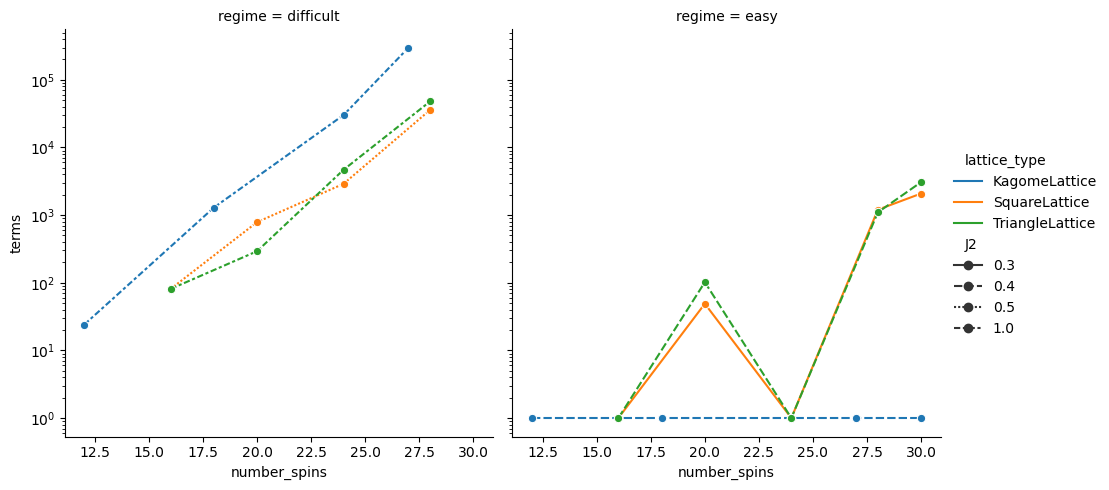

In [56]:
sns.relplot(
    pd.concat(
        [
            series_df.reset_index()
            .query('signal_kind == "sign"')
            .merge(difficult_J2s, on=["lattice_type", "J2"], how="right")
            .assign(regime="difficult"),
            series_df.reset_index()
            .query('signal_kind == "sign"')
            .merge(easy_J2s, on=["lattice_type", "J2"], how="right")
            .assign(regime="easy"),
        ]
    ),
    x="number_spins",
    y="terms",
    hue="lattice_type",
    col='regime',
    kind="line",
    style="J2",
    markers=["o"],
).set(yscale="log")
plt.savefig("fig/boolean-analysis-complexity-3-2.png")

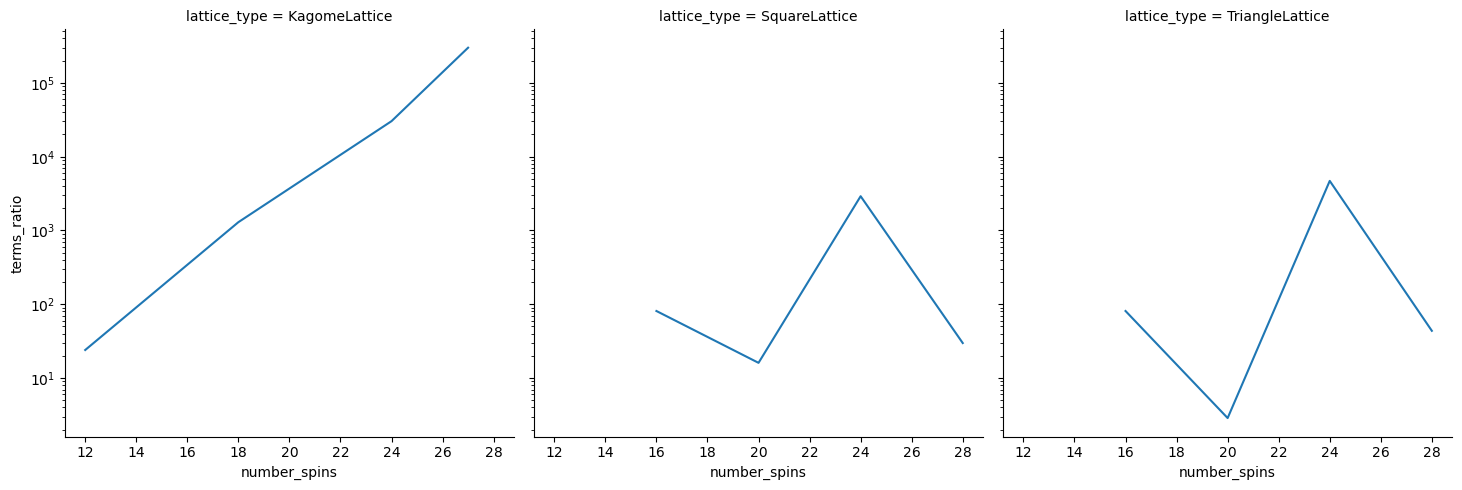

In [68]:
sns.relplot(
    (
        series_df.reset_index()
        .query('signal_kind == "sign"')
        .merge(difficult_J2s, on=["lattice_type", "J2"], how="right")
    )[["lattice_type", "number_spins", "terms"]]
    .merge(
        series_df.reset_index()
        .query('signal_kind == "sign"')
        .merge(easy_J2s, on=["lattice_type", "J2"], how="right")[
            ["lattice_type", "number_spins", "terms"]
        ],
        on=["lattice_type", "number_spins"],
        how="outer",
        suffixes=("_difficult", "_easy"),
    )
    .assign(terms_ratio=lambda df: df.terms_difficult / df.terms_easy),
    x="number_spins",
    y="terms_ratio",
    col="lattice_type",
    kind="line",
).set(yscale="log")

In [55]:
pd.concat(
        [
            series_df.reset_index()
            .query('signal_kind == "sign"')
            .merge(difficult_J2s, on=["lattice_type", "J2"], how="right")
            .assign(regime="difficult"),
            series_df.reset_index()
            .query('signal_kind == "sign"')
            .merge(easy_J2s, on=["lattice_type", "J2"], how="right")
            .assign(regime="easy"),
        ]
    ).query("number_spins == 20 and lattice_type == 'TriangleLattice'")[['J2', 'regime', 'terms']]

,J2,regime,terms
9,1.0,difficult,293
11,0.4,easy,102


/tmp/nix-shell.c6kGom/ipykernel_2070777/1051735163.py:1: UserWarning: 
The markers list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.relplot(


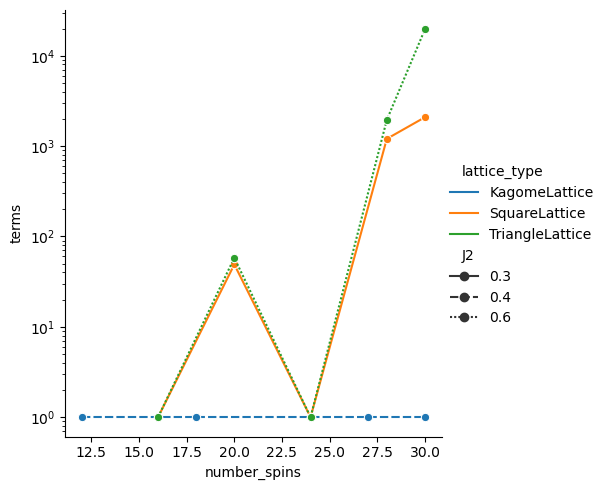

In [45]:
sns.relplot(
    series_df.reset_index()
    .query('signal_kind == "sign"')
    .merge(easy_J2s, on=["lattice_type", "J2"], how="right"),
    x="number_spins",
    y="terms",
    hue="lattice_type",
    kind="line",
    style="J2",
    markers=['o']
).set(yscale="log")
plt.savefig("fig/boolean-analysis-complexity-4.png")

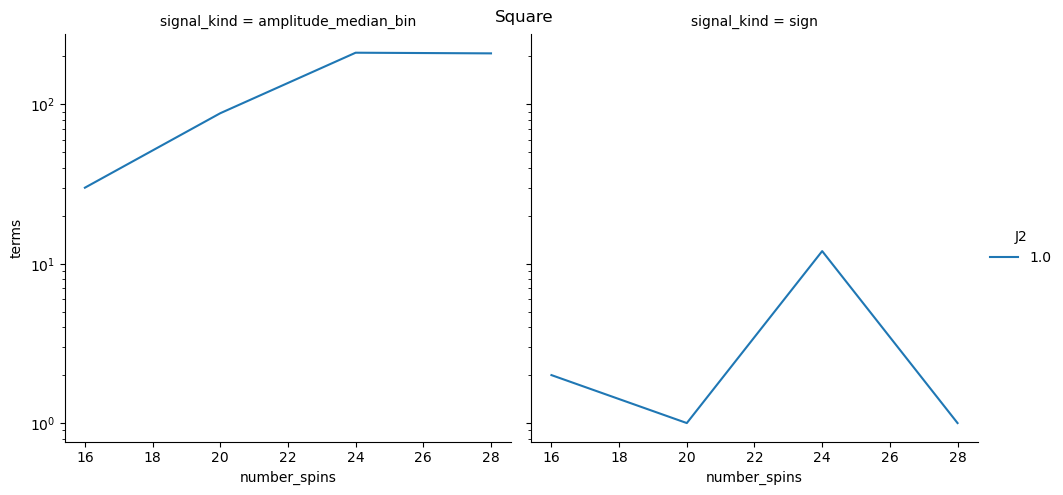

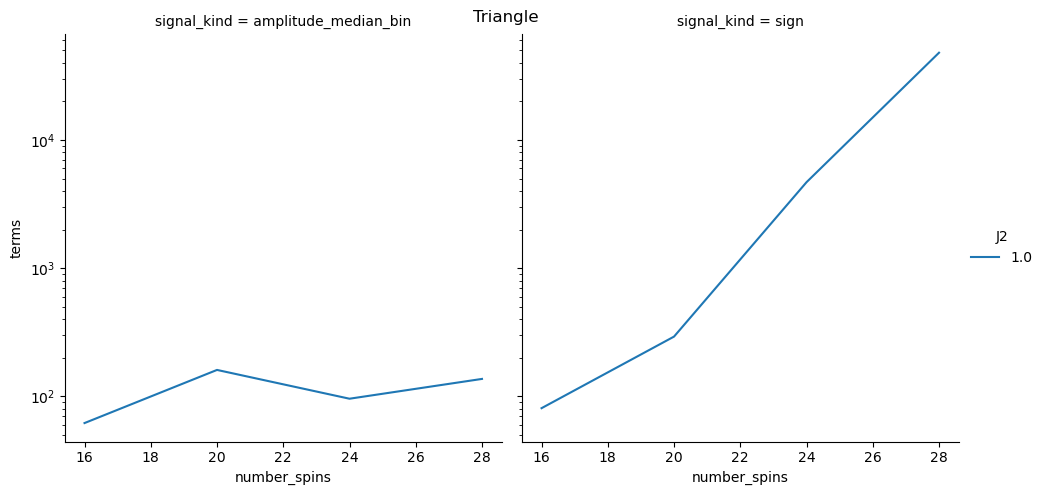

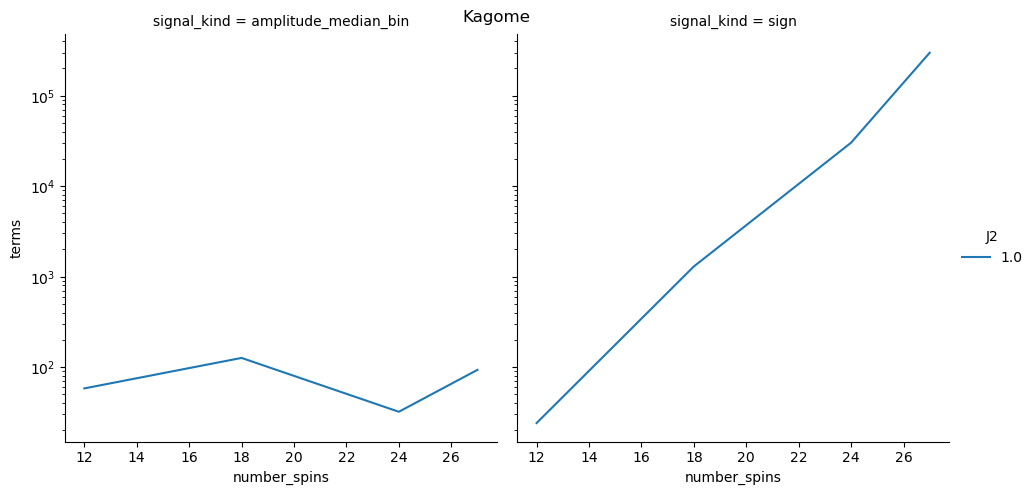

In [14]:
for lat in ["Square", "Triangle", "Kagome"]:
    plot = sns.relplot(
        series_df.reset_index()
        .query("lattice_name.str.startswith(@lat) and J2==1")
        .assign(J2=lambda df: df["J2"].astype(str)),
        x="number_spins",
        y="terms",
        col="signal_kind",
        hue="J2",
        kind="line",
        markers=True,
    ).set(yscale="log")
    plot.fig.suptitle(lat)

In [24]:
def plot_subsets(subsets, titles, lat: SpinLattice):
    fig, axes = plt.subplots(
        1, len(subsets), figsize=(len(subsets) * 3, 3), squeeze=False
    )
    for ax, subset, title in zip(axes[0], subsets, titles):
        lat.plot(spins=subset, ax=ax)
        ax.axis("off")
        ax.set_title(title)
    return fig

In [25]:
def plot_subsets_df(lattice_name, J2, signal_kind):
    row = (
        series_df.reset_index()
        .query("lattice_name == @lattice_name and J2 == @J2 and signal_kind == @signal_kind")
        .iloc[0]
    )
    
    subsets = row["largest_terms"][:7]
    coeffs = row["largest_coeffs"][:7]

    fig = plot_subsets(subsets, coeffs, name_to_lat_and_sym[lattice_name][0])
    fig.suptitle(f"{lattice_name}, J2 = {J2}, {signal_kind}")
    fig.tight_layout()

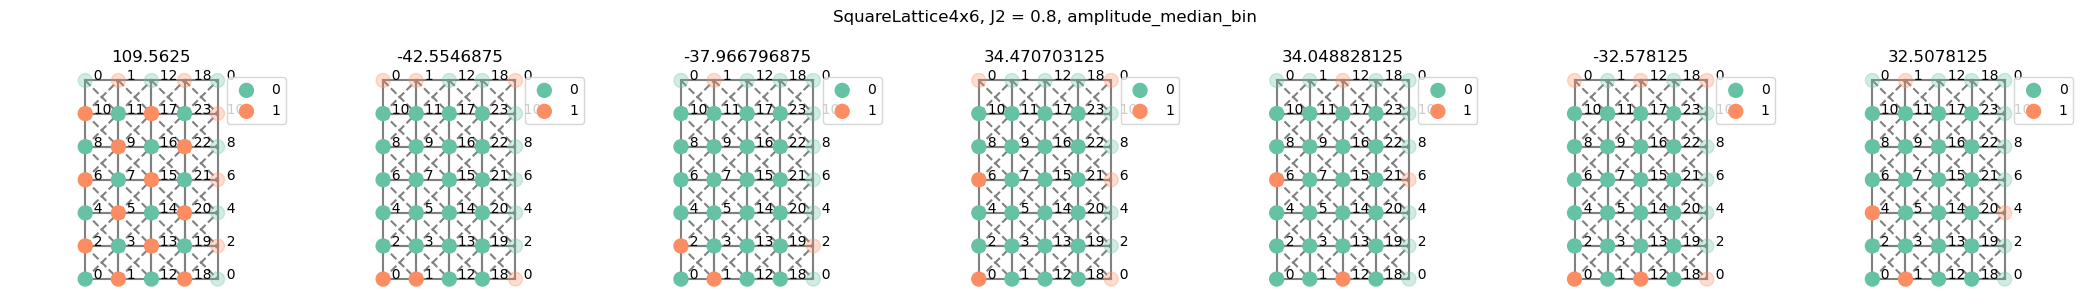

In [27]:
plot_subsets_df("SquareLattice4x6", 0.8, "amplitude_median_bin")
# plt.savefig("fig/boolean-analysis-complexity-6-1.png")

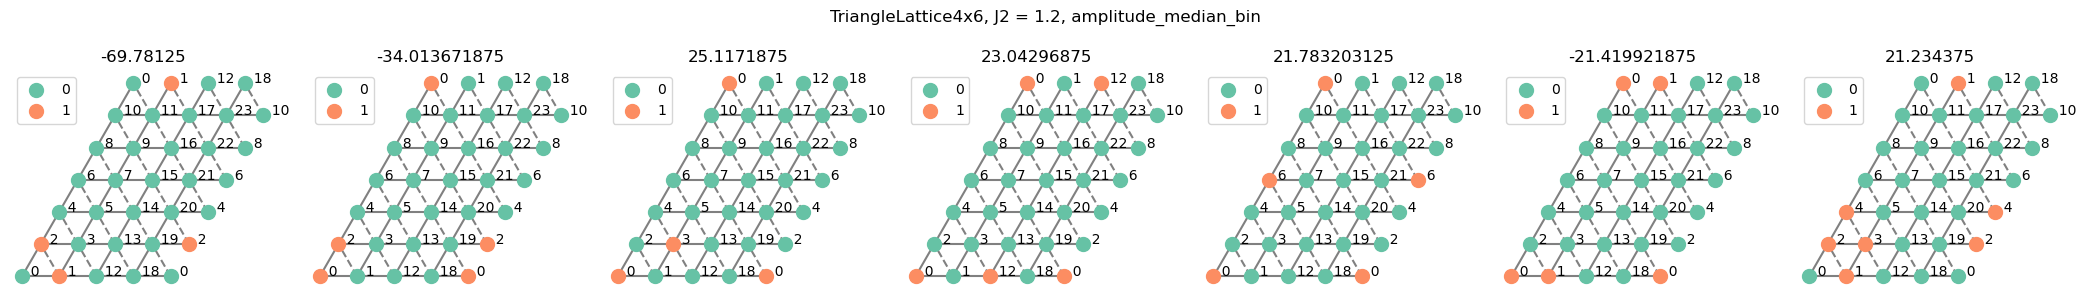

In [16]:
plot_subsets_df("TriangleLattice4x6", 1.2, "amplitude_median_bin")
# plt.savefig("fig/boolean-analysis-complexity-6-2.png")

In [94]:
series_df.reset_index()['lattice_name'].unique()

array(['KagomeLattice2x2', 'KagomeLattice2x3', 'KagomeLattice2x4',
       'KagomeLattice3x3', 'KagomeLattice2x5', 'SquareLattice4x4',
       'SquareLattice4x5', 'SquareLattice4x6', 'SquareLattice7x4',
       'SquareLattice5x6', 'TriangleLattice4x4', 'TriangleLattice4x5',
       'TriangleLattice4x6', 'TriangleLattice7x4', 'TriangleLattice5x6'],
      dtype=object)

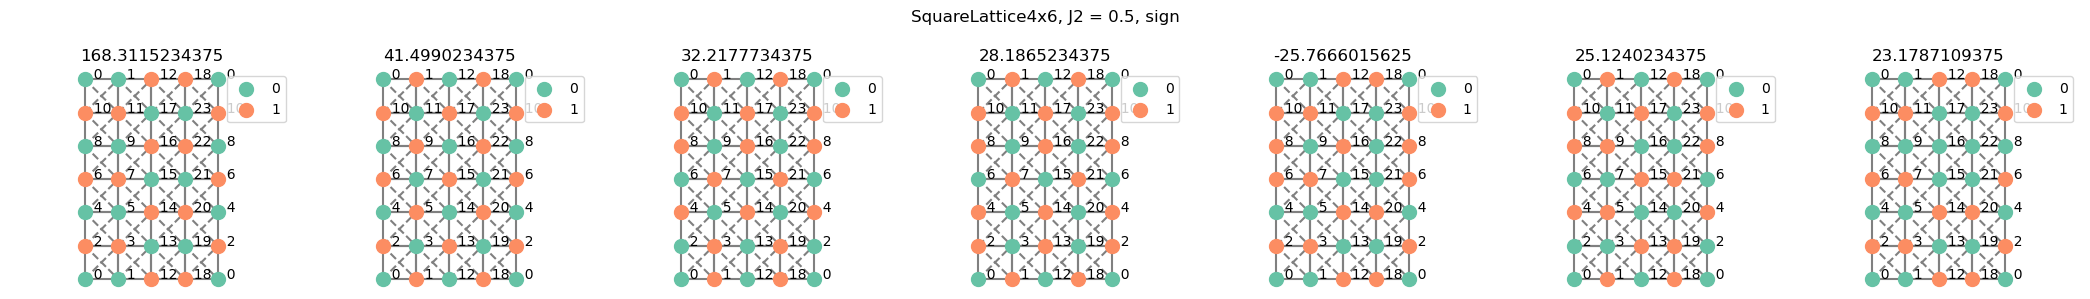

In [95]:
plot_subsets_df("SquareLattice4x6", 0.5, "sign")
plt.savefig("fig/boolean-analysis-complexity-6-3.png")

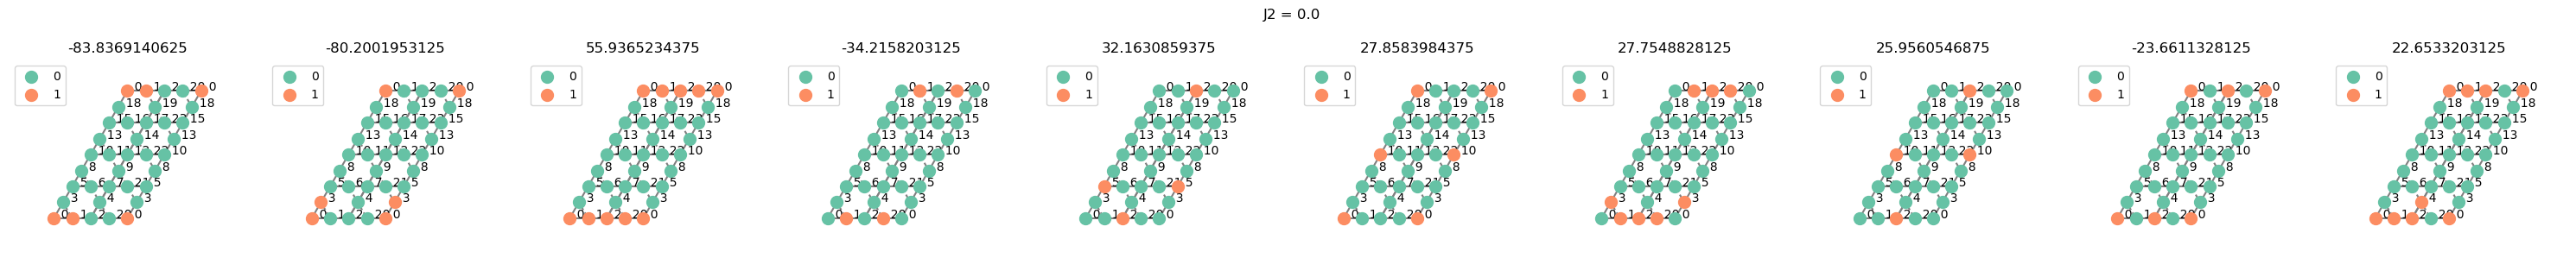

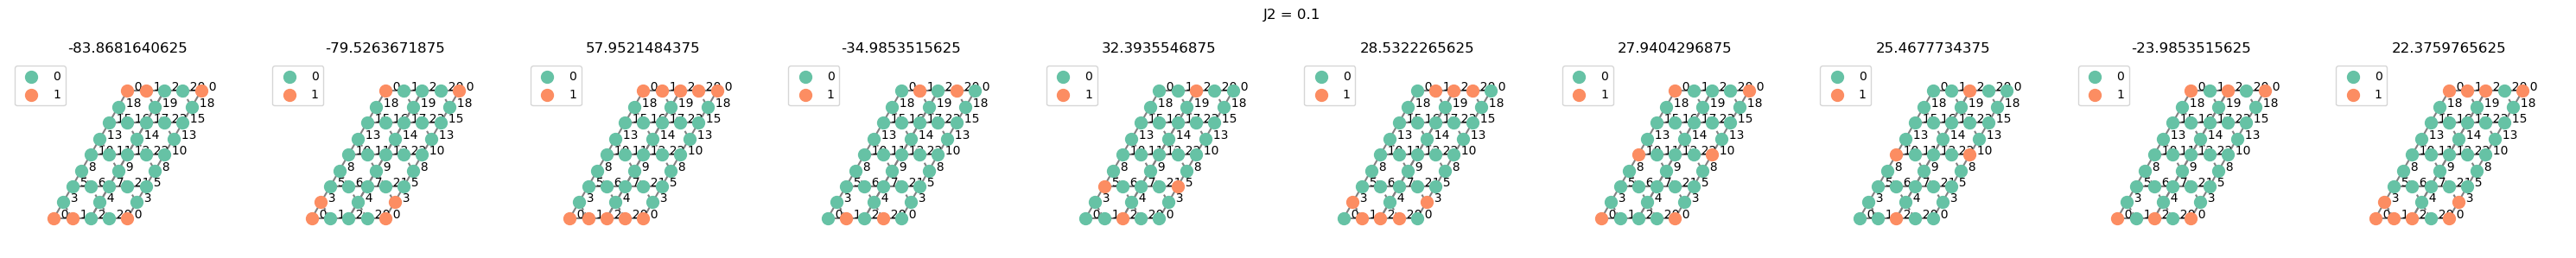

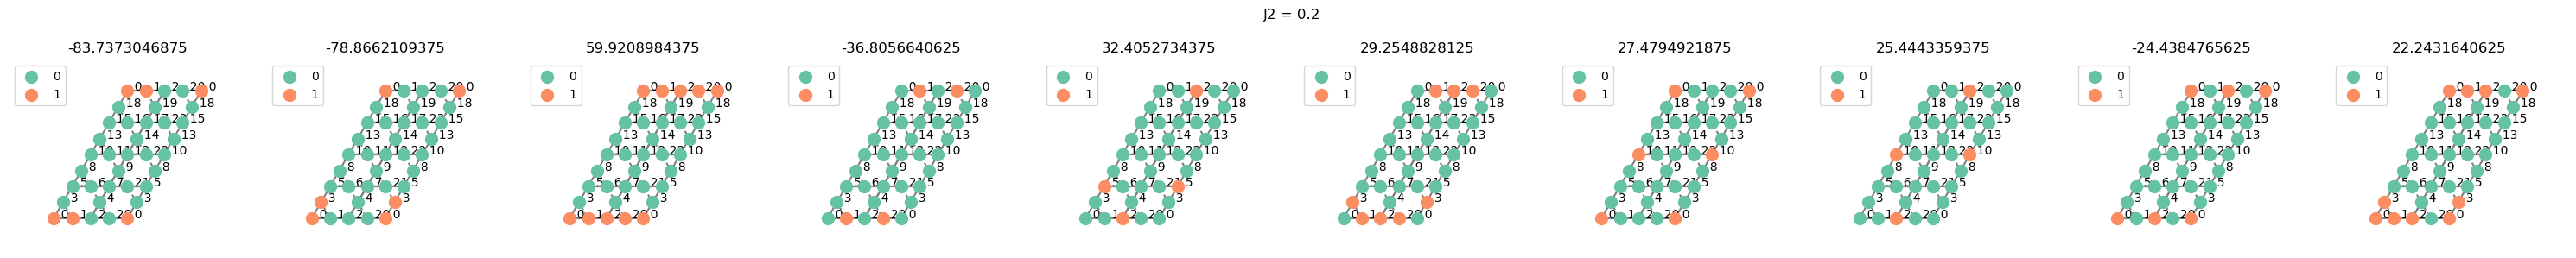

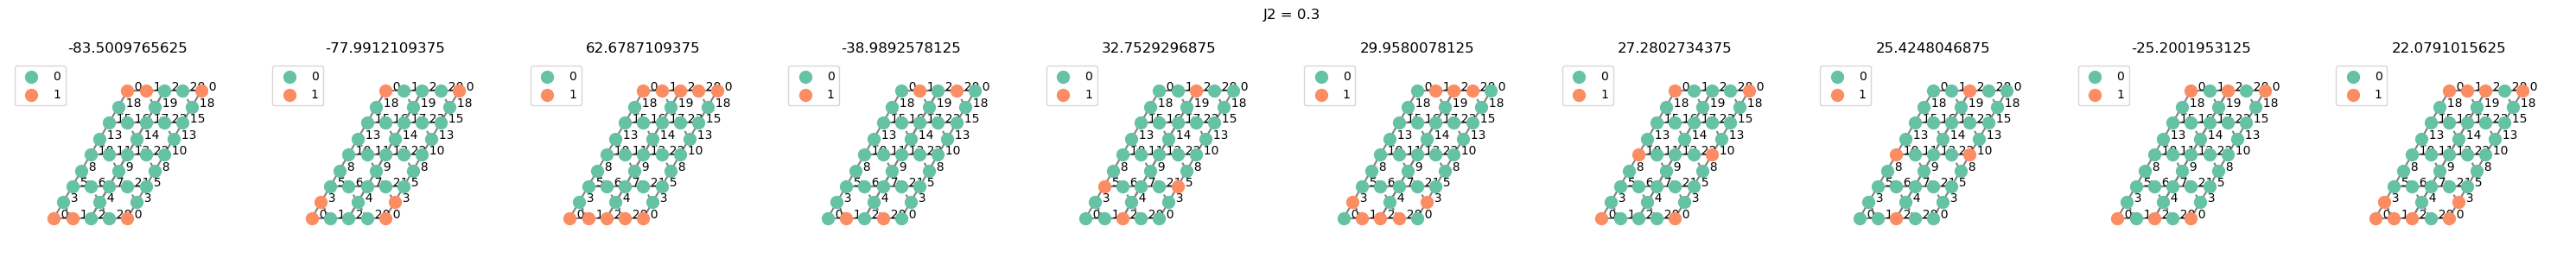

Error in callback <function flush_figures at 0x1512485d9480> (for post_execute):


KeyboardInterrupt: 

In [75]:
lattice_name = "KagomeLattice2x4"
signal = "amplitude_median_bin"

for J2, row in (
    series_df.sort_index(level="J2")
    .xs((lattice_name, signal), level=("lattice_name", "signal_kind"))
    .iterrows()
):
    subsets = row["largest_terms"]
    coeffs = row["largest_coeffs"]

    fig = plot_subsets(subsets, coeffs, name_to_lat_and_sym[lattice_name][0])
    fig.suptitle(f"J2 = {J2}")
    fig.tight_layout()
    fig.show()

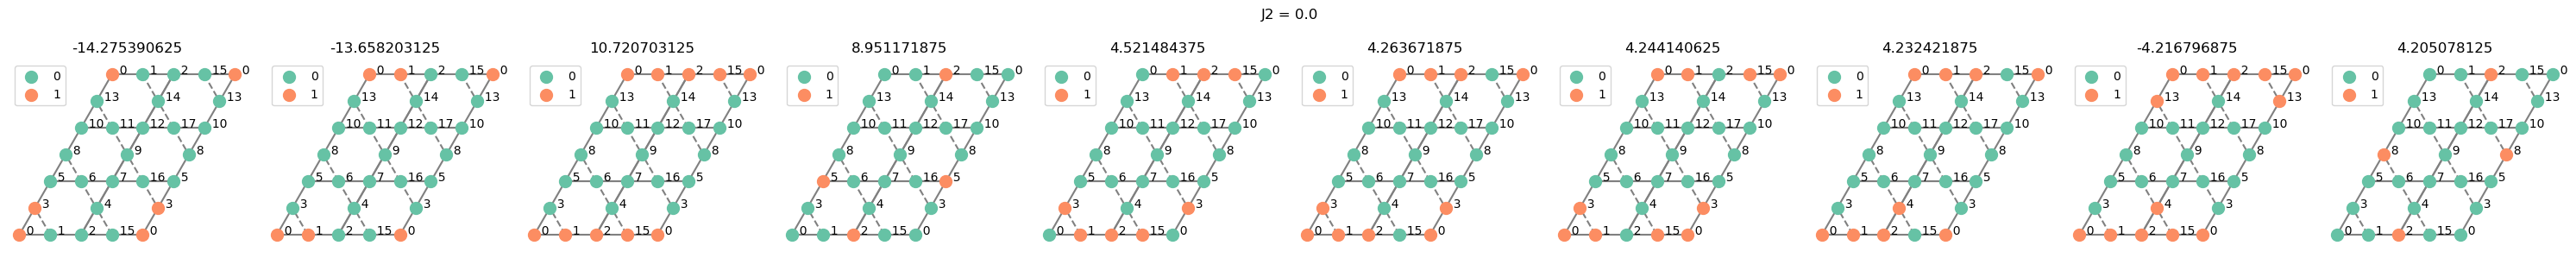

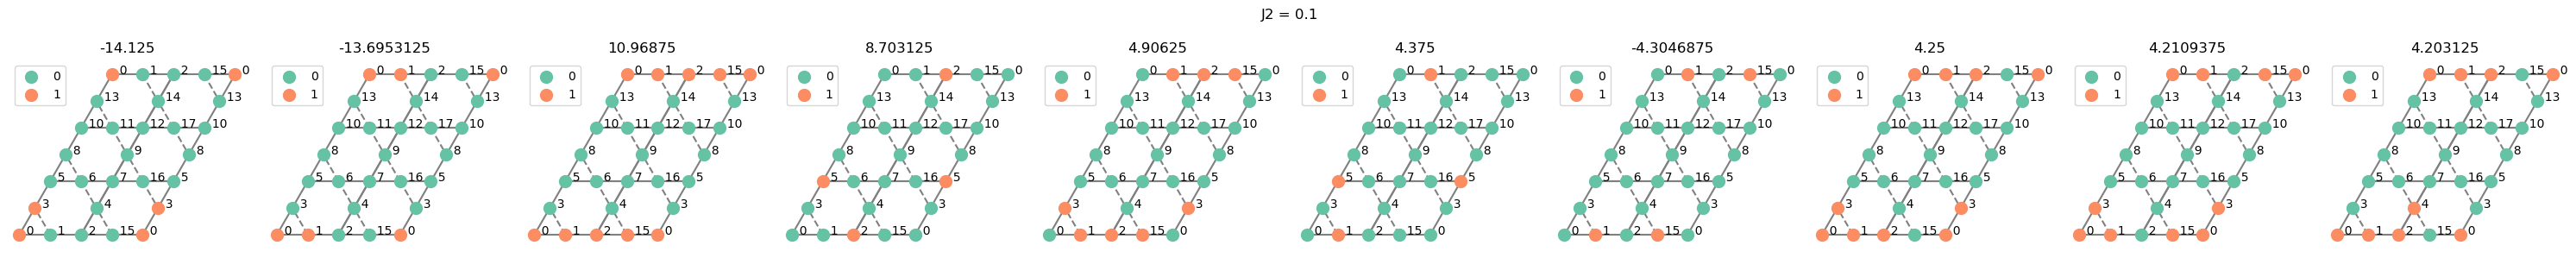

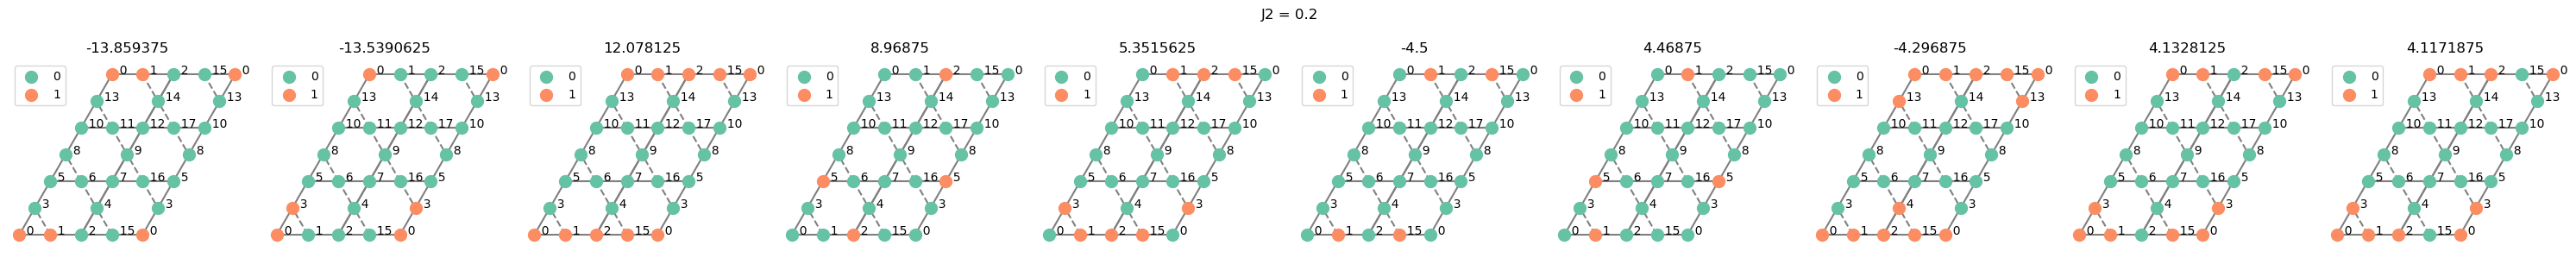

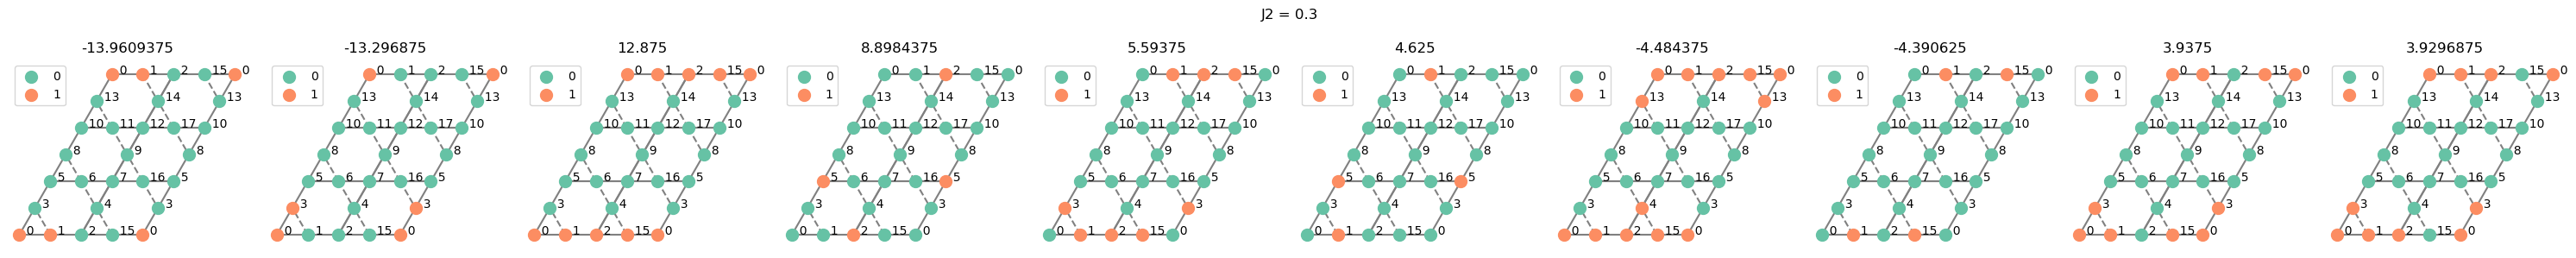

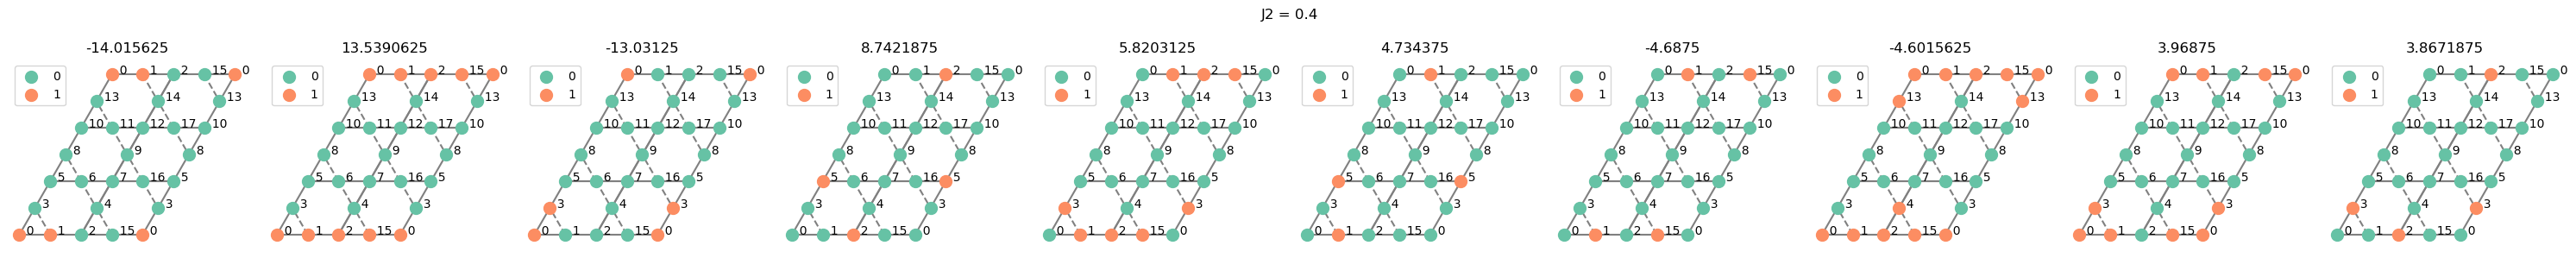

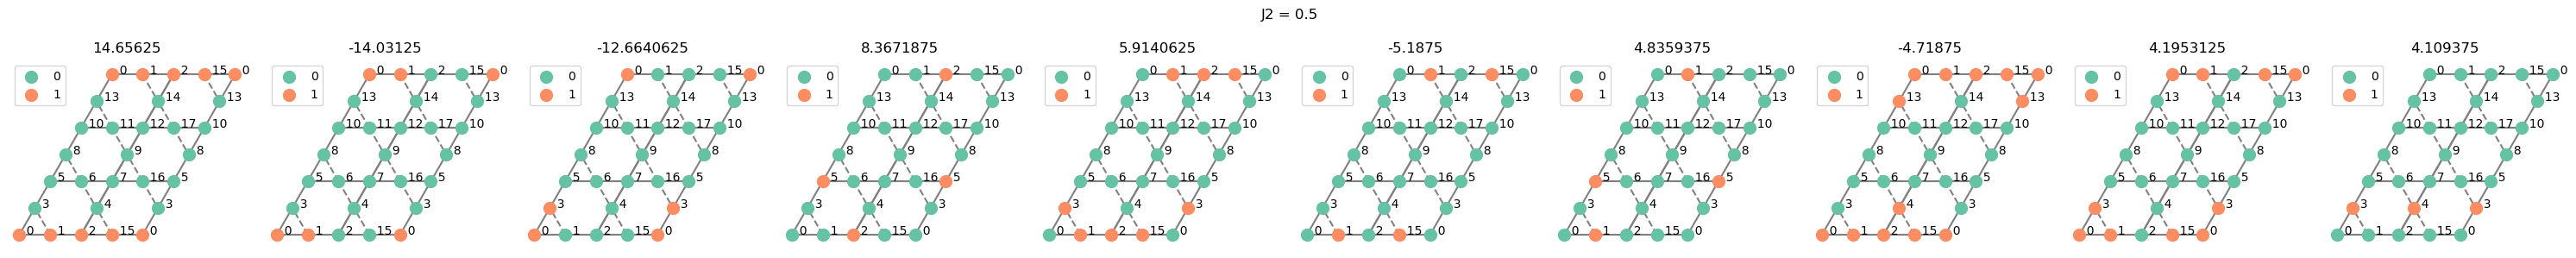

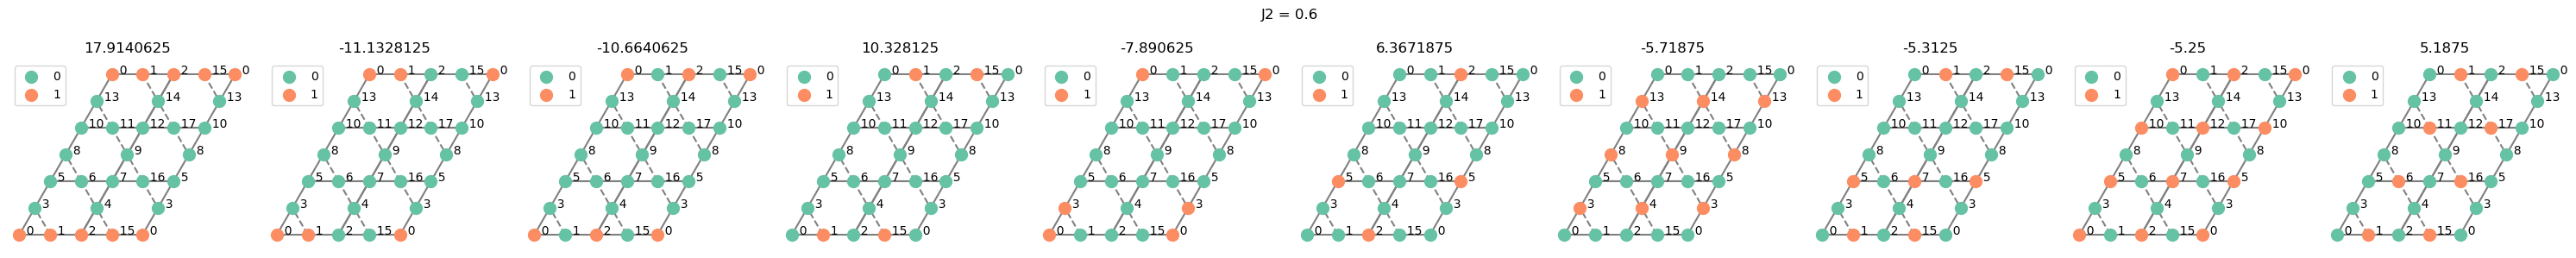

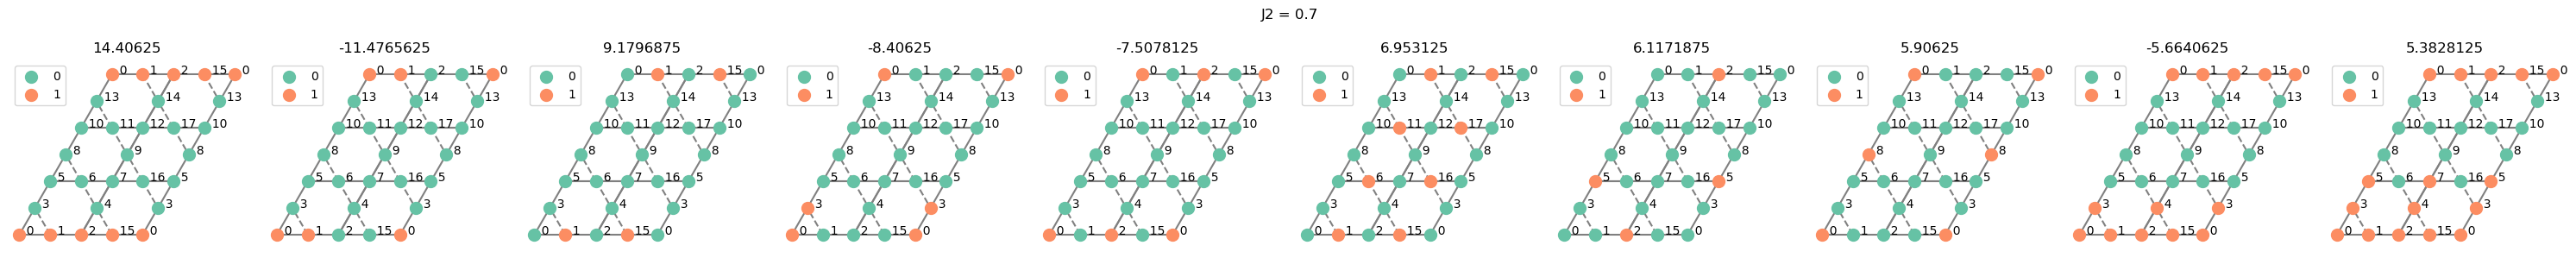

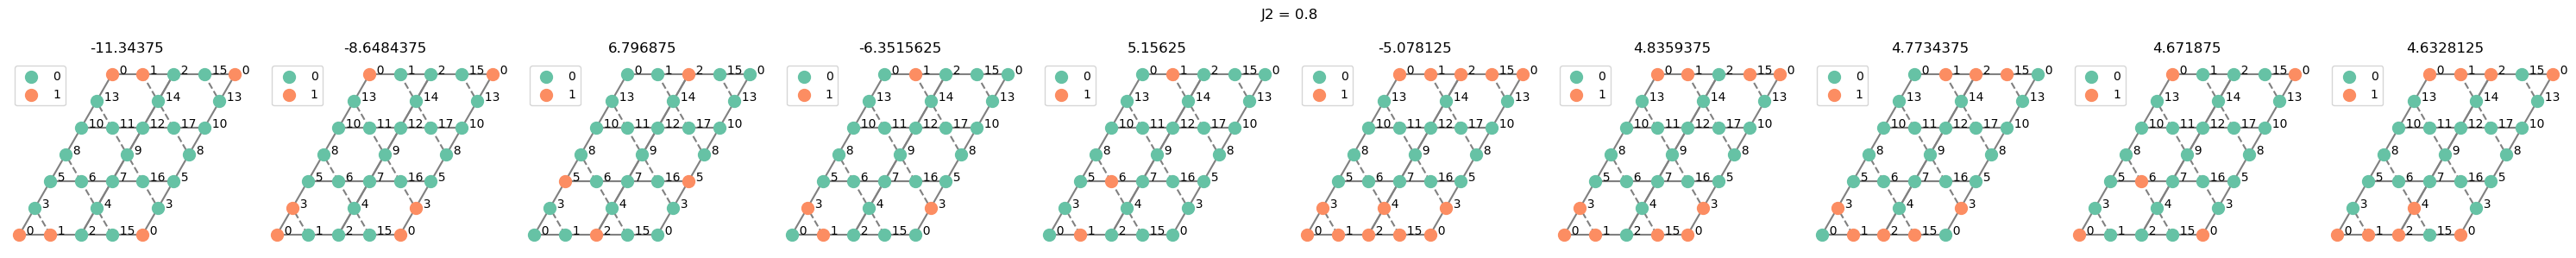

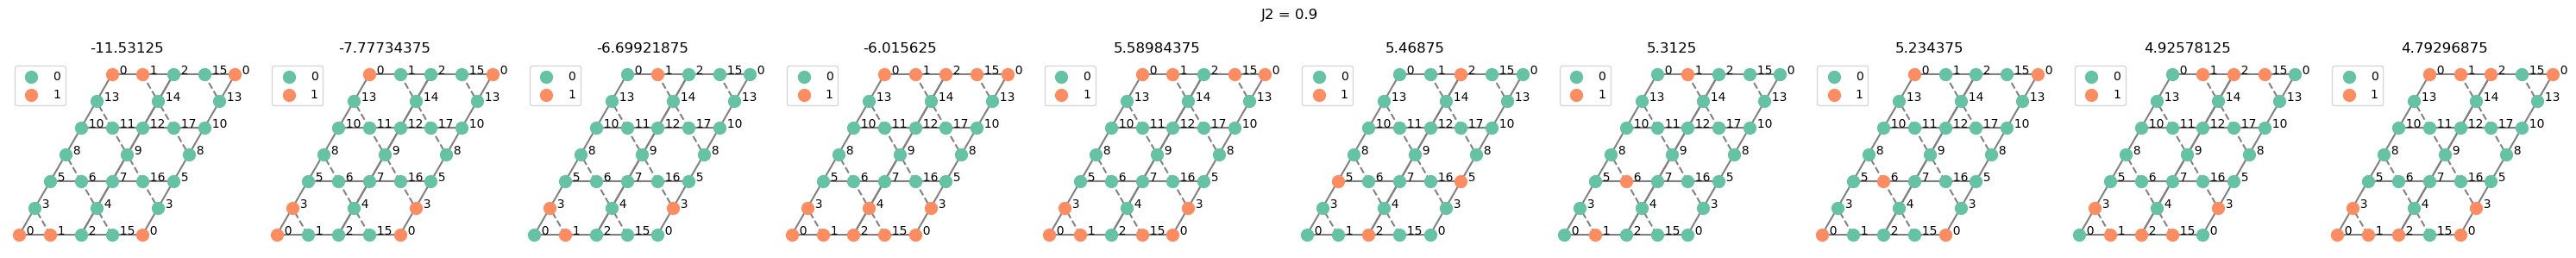

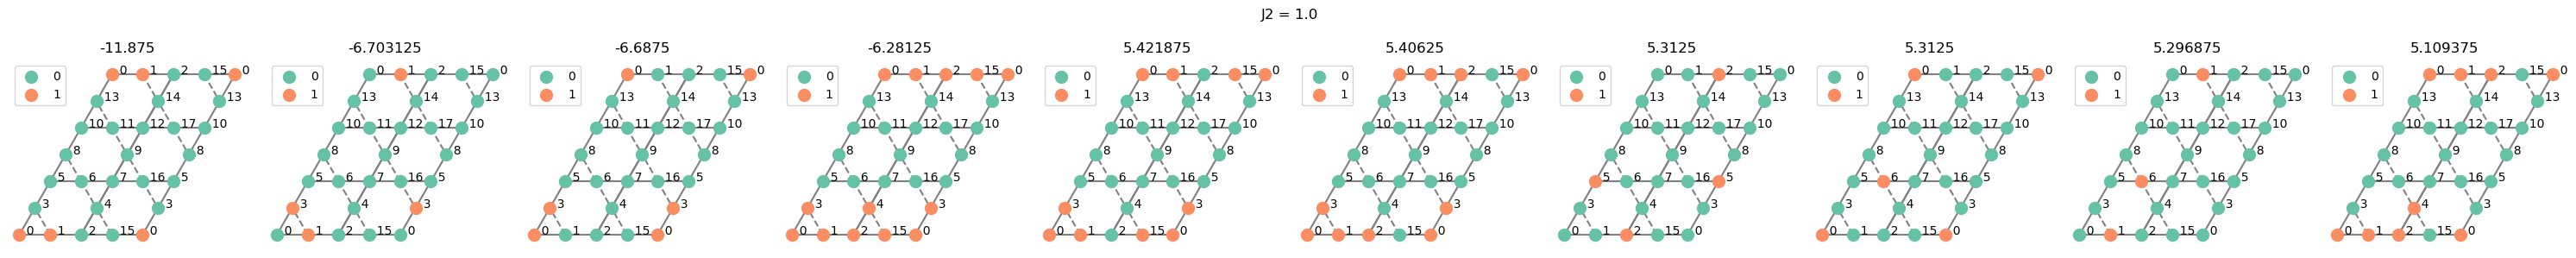

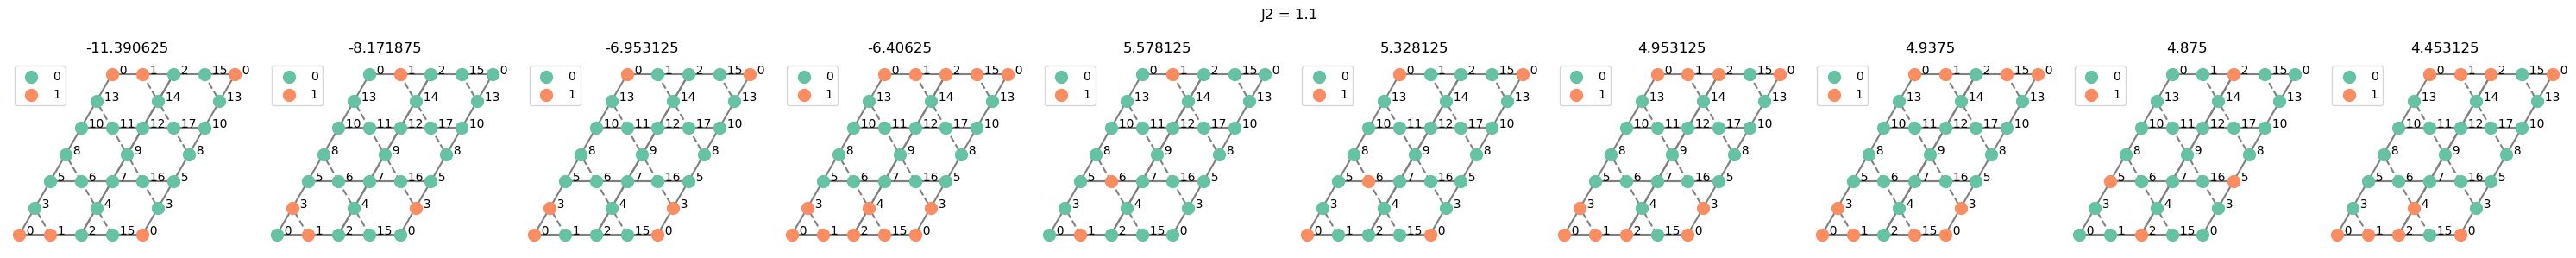

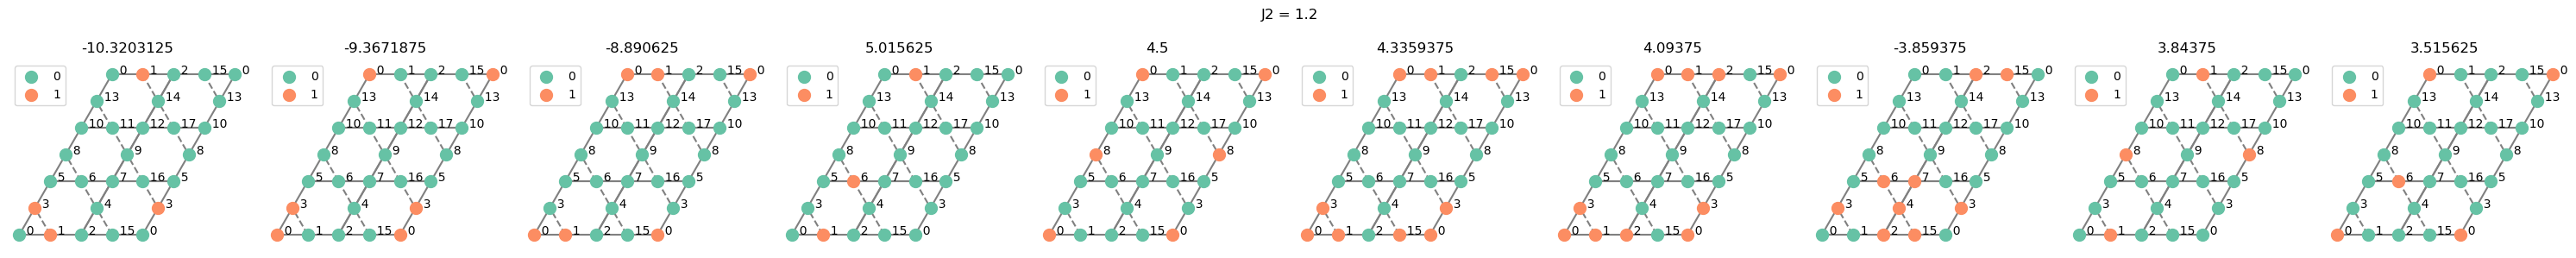

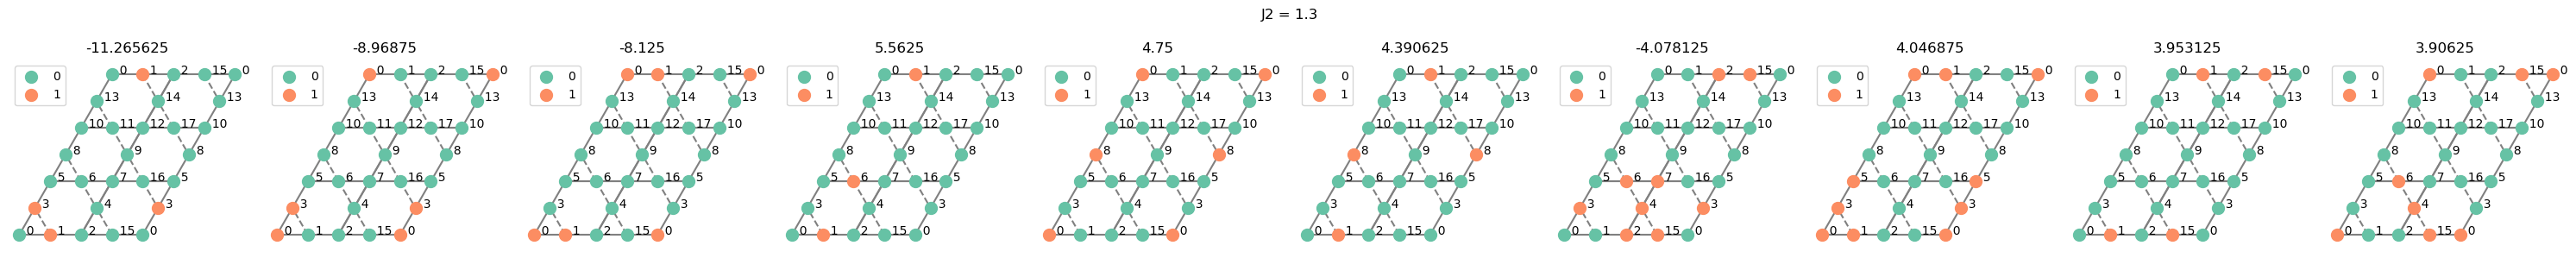

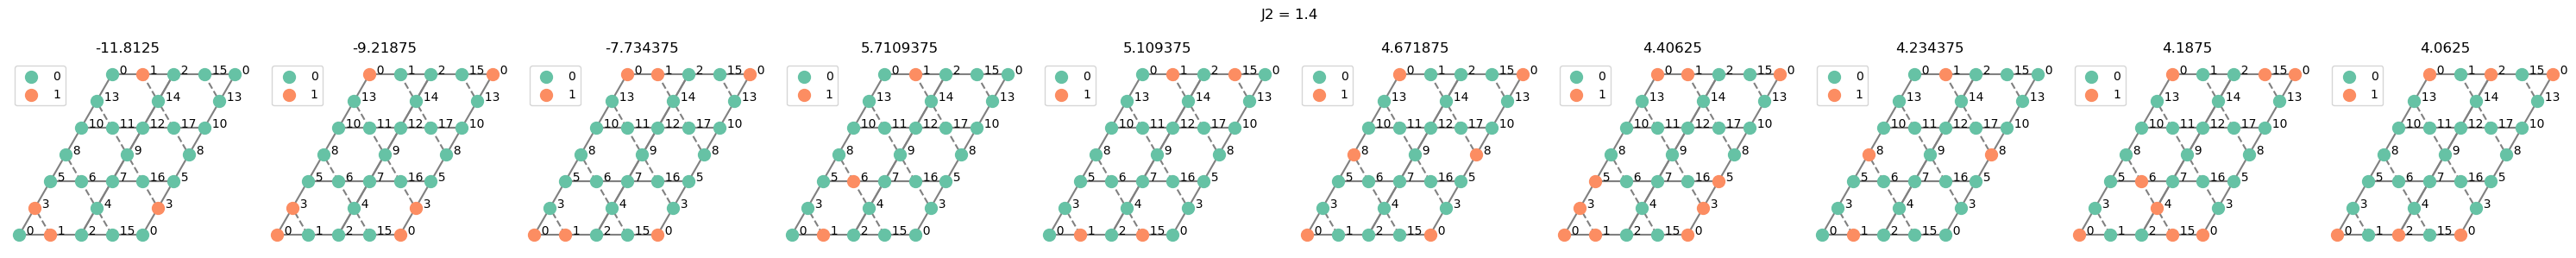

In [13]:
lattice_name = "KagomeLattice2x3"
signal = "amplitude_median_bin"

for J2, row in (
    series_df.sort_index(level="J2")
    .xs((lattice_name, signal), level=("lattice_name", "signal_kind"))
    .iterrows()
):
    subsets = row["largest_terms"]
    coeffs = row["largest_coeffs"]

    fig = plot_subsets(subsets, coeffs, name_to_lat_and_sym[lattice_name][0])
    fig.suptitle(f"J2 = {J2}")
    fig.tight_layout()
    fig.show()

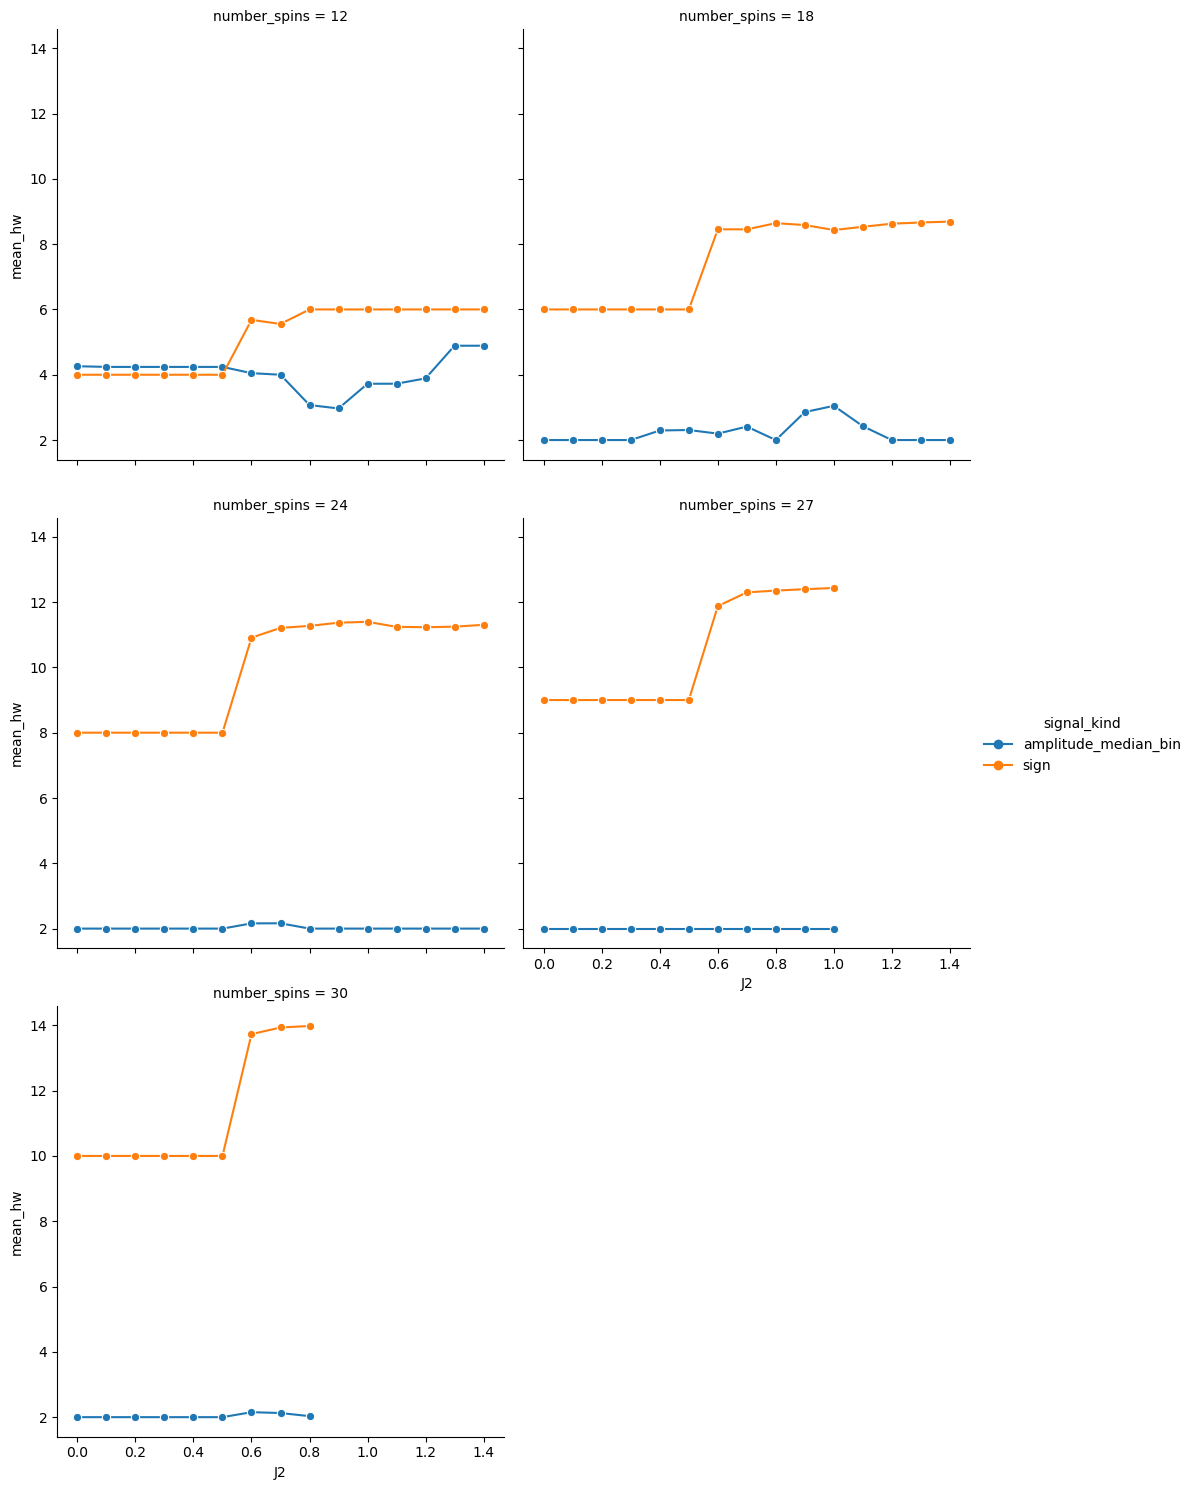

In [17]:
sns.relplot(
    series_df.query("lattice_name.str.startswith('Kagome')"),
    x="J2",
    y="mean_hw",
    hue="signal_kind",
    col="number_spins",
    col_wrap=2,
    kind="line",
    dashes=False,
    style="signal_kind",
    markers=["o", "o"],
)

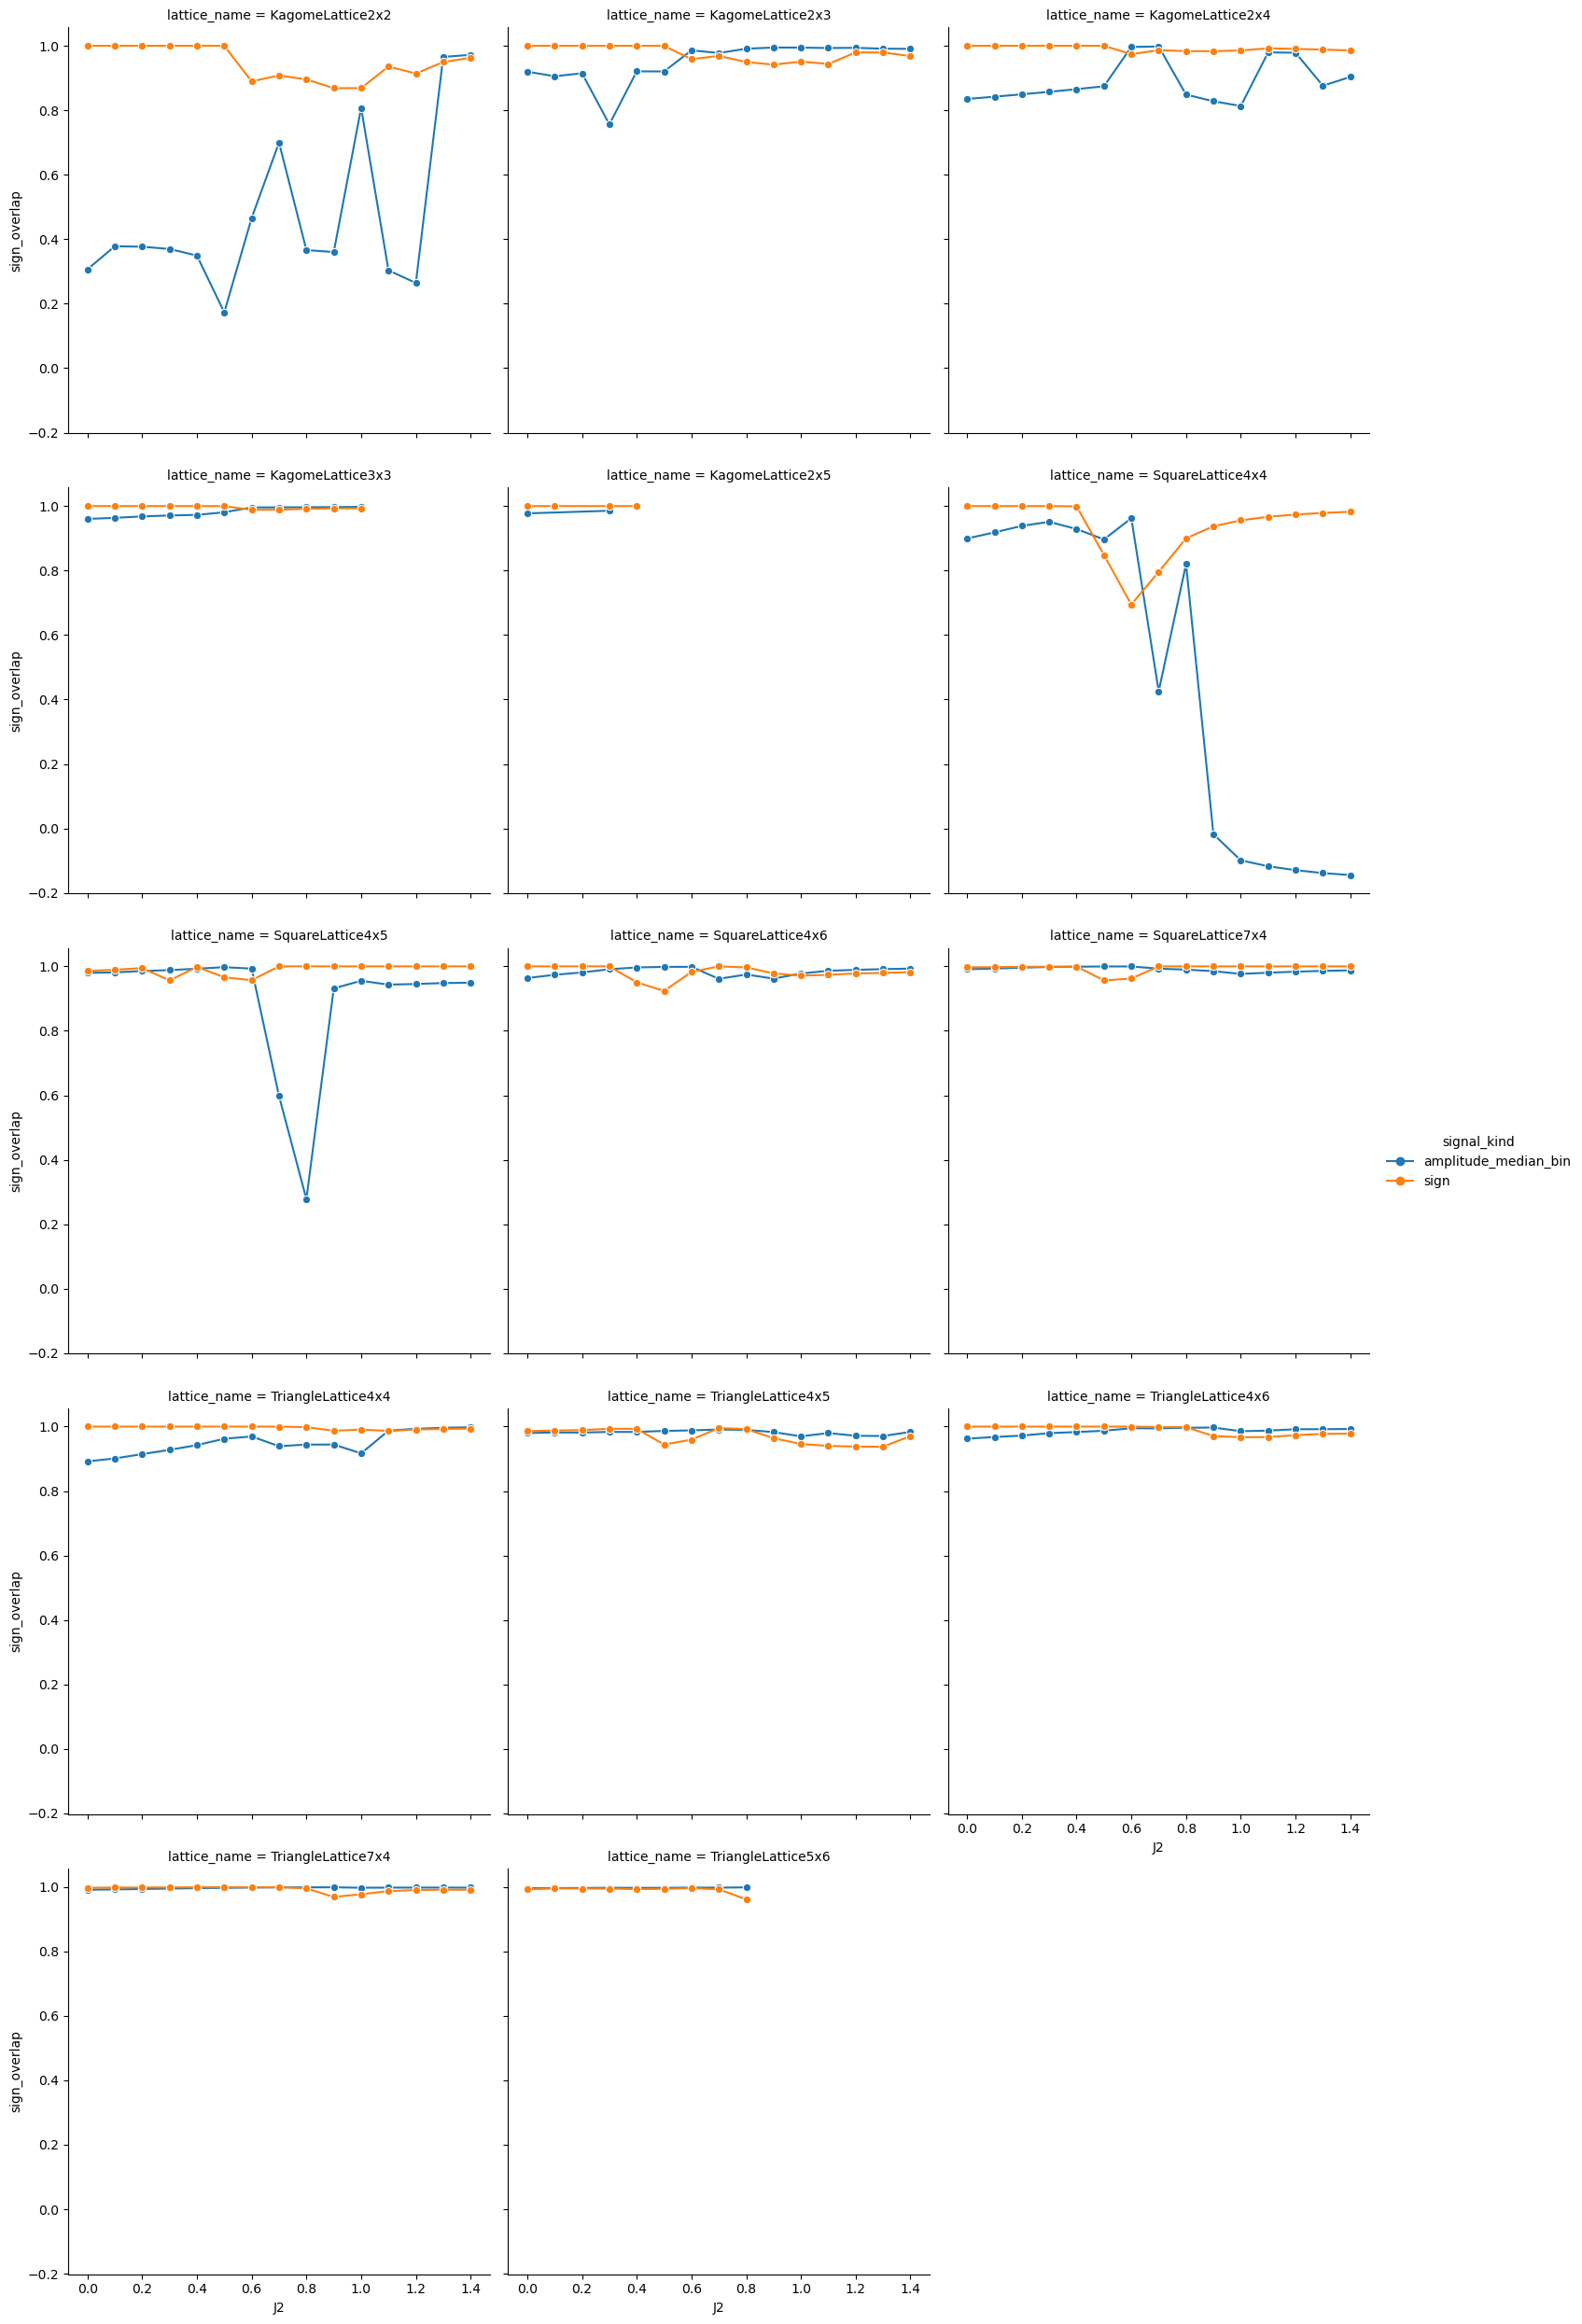

In [36]:
sns.relplot(
    series_df.reset_index(),
    x="J2",
    y="sign_overlap",
    hue="signal_kind",
    col="lattice_name",
    col_wrap=3,
    kind="line",
    dashes=False,
    style="signal_kind",
    markers=["o", "o"],
)

In [54]:
complexity_ratio_df = (
    series_df.unstack(level="signal_kind")["total_hamming_weight"]
    .assign(
        ratio=lambda df: df["sign"] / df["amplitude_median_bin"],
        number_spins=lambda df: df.index.map(
            lambda name: name_to_lat_and_sym[name[0]][0].number_spins
        ),
        lattice_type=lambda df: df.index.map(
            lambda name: re.sub(
                r"\d.+", "", name_to_lat_and_sym[name[0]][0].get_cache_id()
            )
        ),
    )
    .reset_index()
)

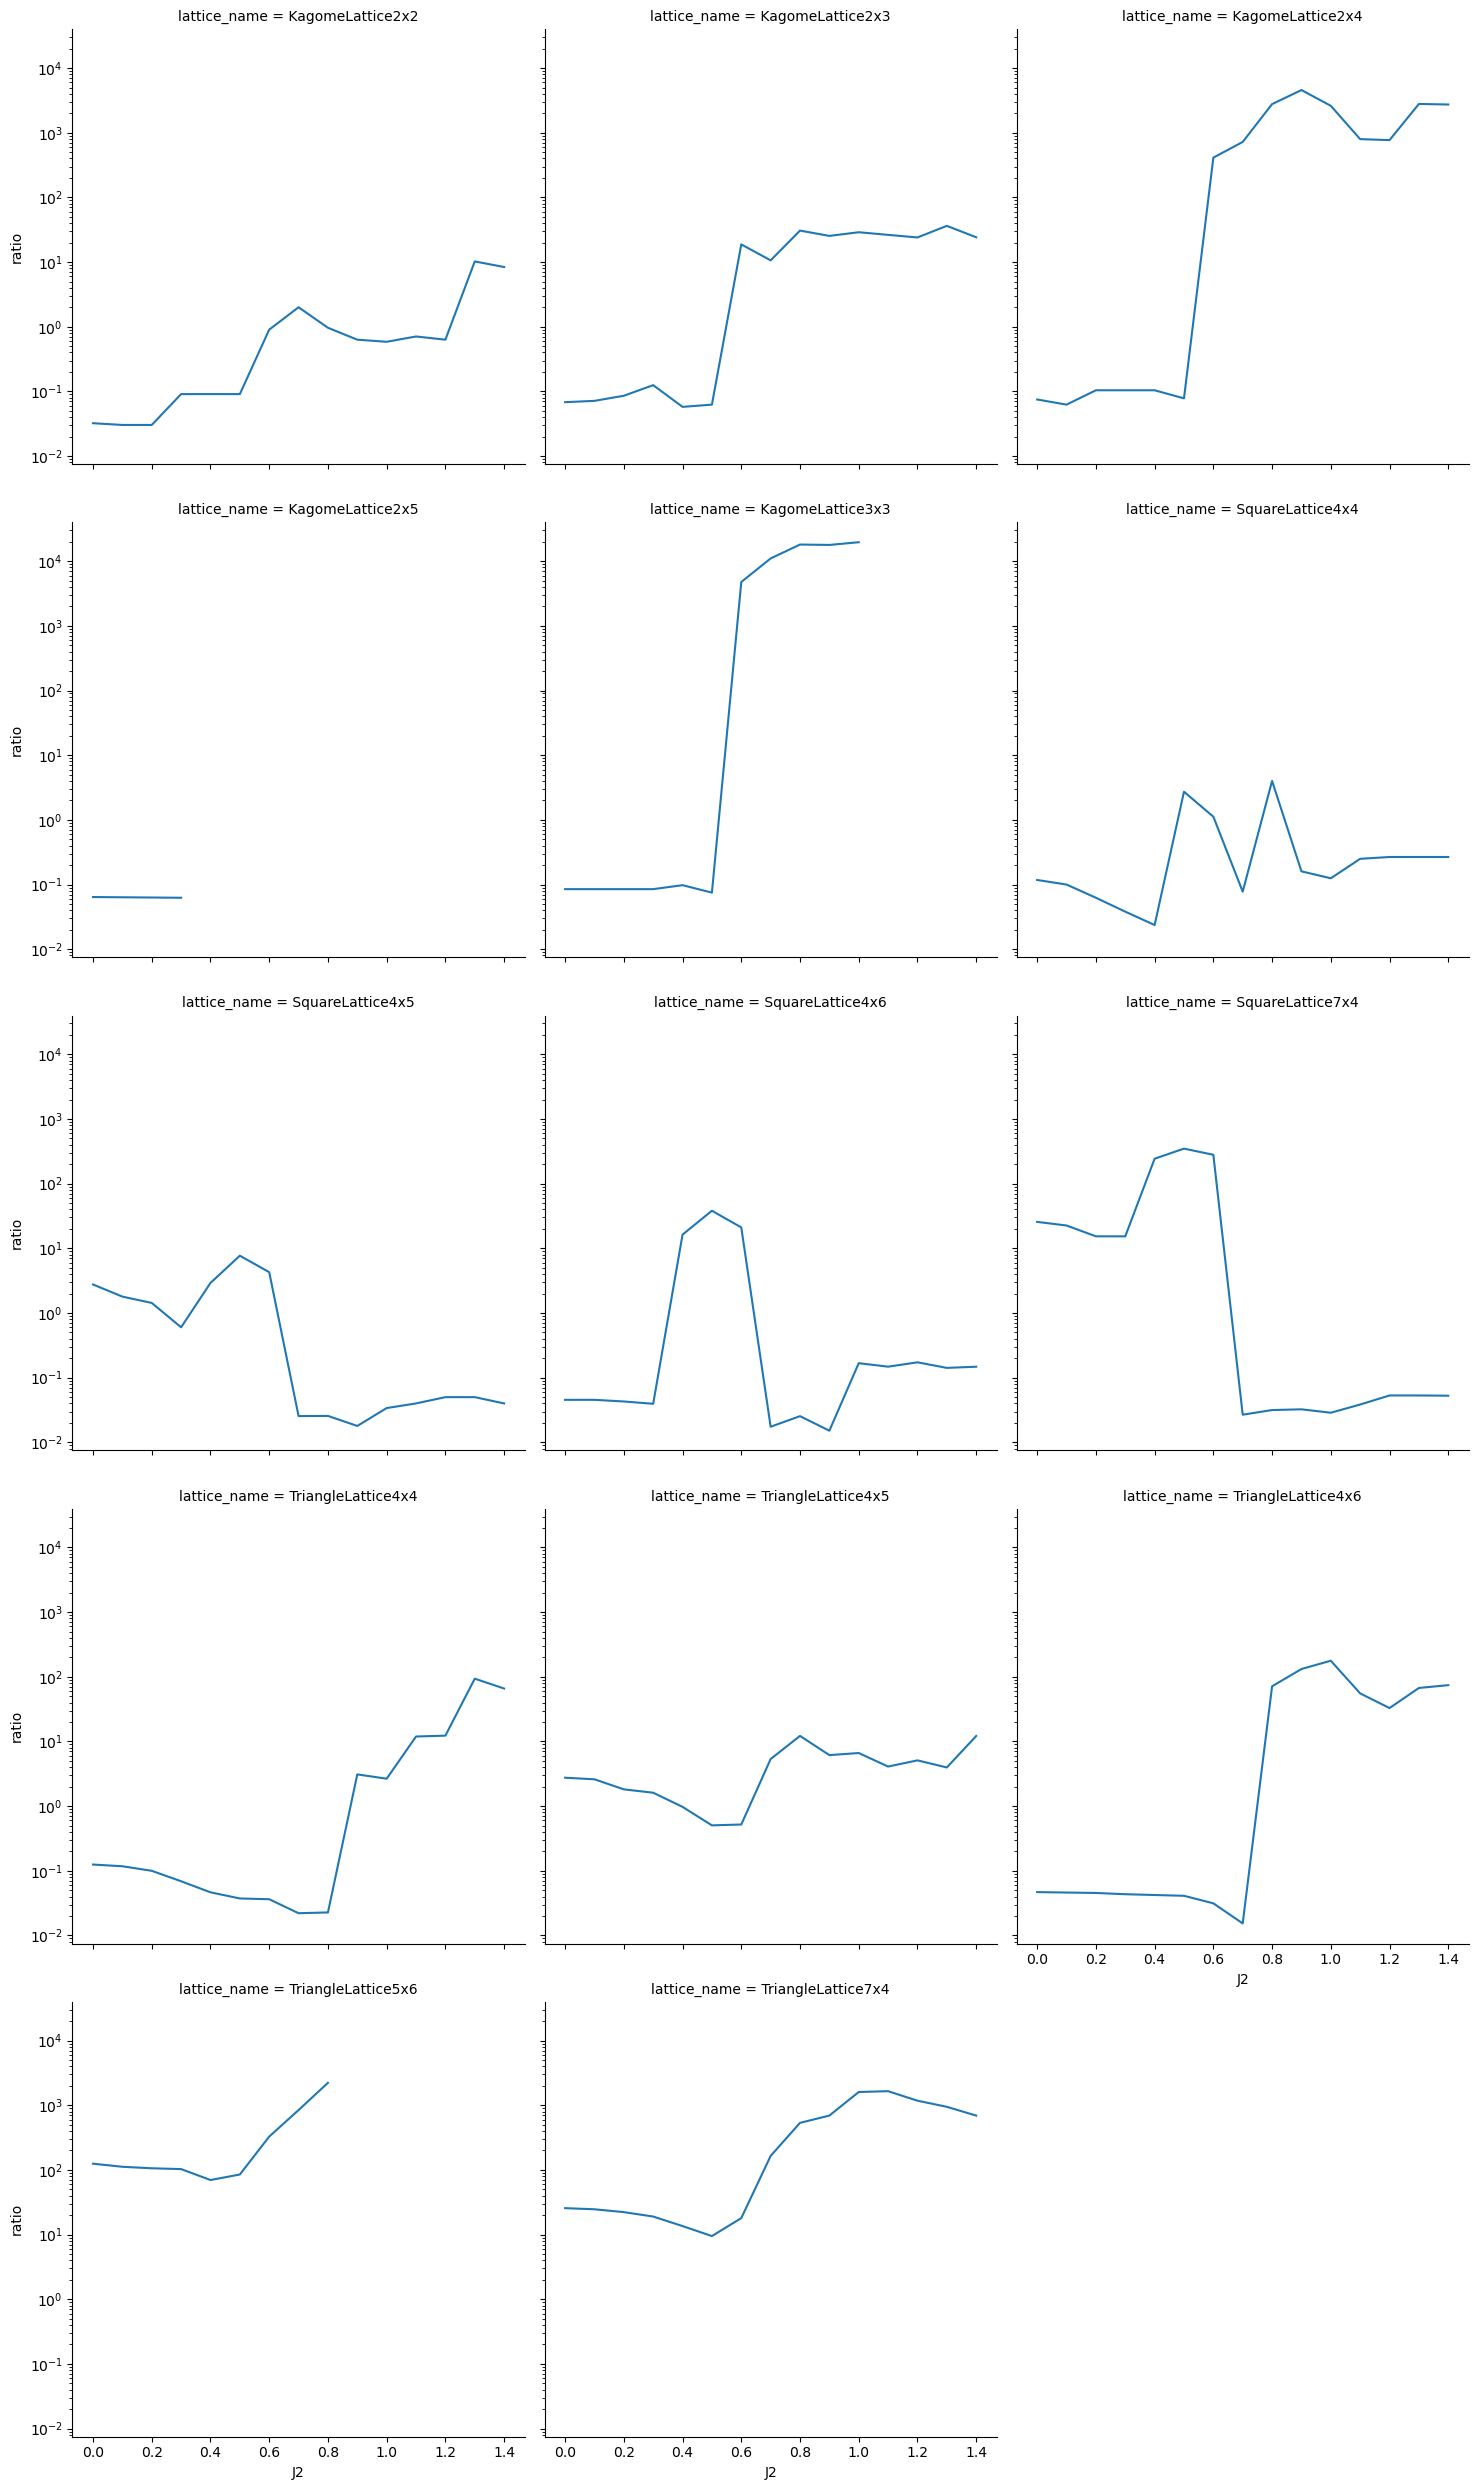

In [39]:
sns.relplot(
    complexity_ratio_df, x="J2", y="ratio", col="lattice_name", col_wrap=3, kind="line"
).set(yscale="log")

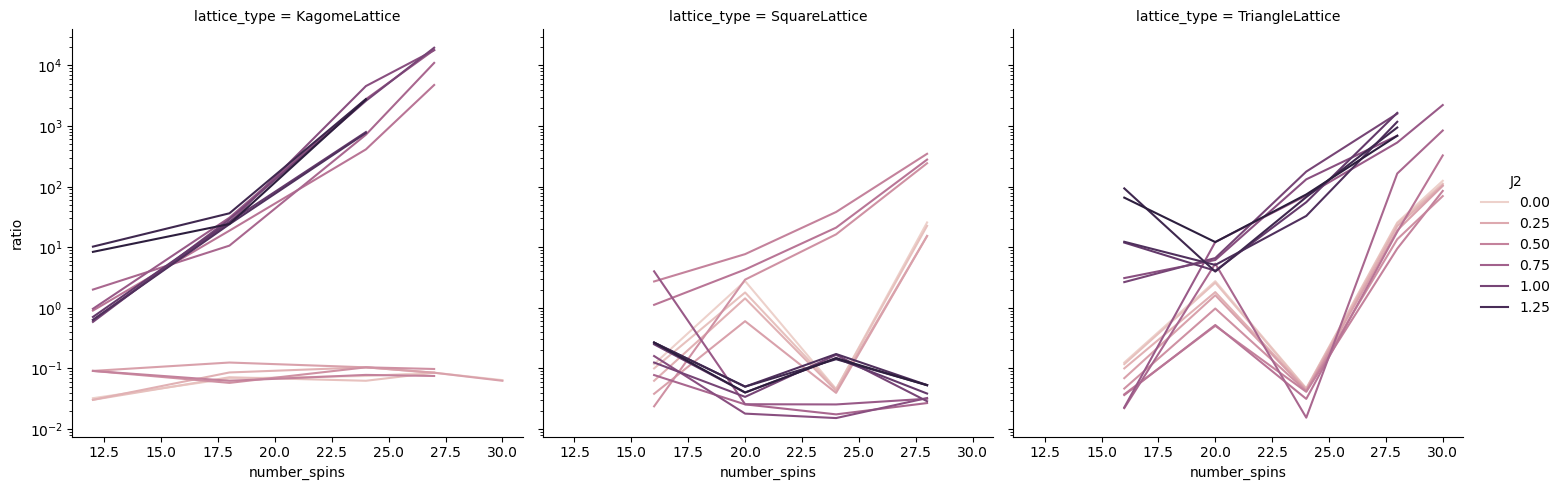

In [55]:
sns.relplot(
    complexity_ratio_df,
    x="number_spins",
    col="lattice_type",
    col_wrap=3,
    y="ratio",
    hue="J2",
    kind="line",
).set(yscale="log")